# 다이캐스팅 공정 데이터 EDA + 모델링 파이프라인
> **구성**: 데이터 로드 → 구조 파악 → 중복 확인 → 결측값 처리 → 이상치 처리 → 타겟/파생변수 생성 → 시각화 → 상관분석 → 모델링

> **이상치 처리 합의 (260303 정규 회의)**
> - Velocity=0 (4건) → 삭제
> - Cycle_Time 극단값 → 공정 지연 신호로 유지 (Capping 제외)
> - 극단값 절사 기준 → IQR / 1% / 0.5% 실험 후 비교
> - Velocity_2 이상치 184건 → 추가 조사 중 (미결)

> **SMOTE 미적용** — 불량률 22.4%로 심각한 불균형 아님, class_weight로 대응

## STEP 0. 라이브러리 임포트 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 (멀티헤더)
df_raw = pd.read_csv(
    "../../data/DieCasting_Quality_Raw_Data.csv",
    header=[0, 1]
)
print(f"원본 Shape: {df_raw.shape}")
df_raw.head(5)

원본 Shape: (7535, 57)


Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                        ...     Defects  \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness   ... Blow_Hole_2   
0               214           0.008                 10  ...           0   
1               217           0.008                 11  ...           0   
2               214           0.008                 11  ...           0   
3               217           0.008                 11  ...           0   
4               217           0.008                 12  ...           0   

                                                                             \
  Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2 Scratch_2   
0       0      0             0               0          0       0         0   
1       0      0             0               0          0       0         0   
2       0      0             0               0          0       0         0   
3       0      0             0               0          0       0         0   
4       0      0             0               0          0       0         0   

                              
  Buring_Mark_2 Inclusions_2  
0             0            0  
1             0            0  
2             0            0  
3             0            0  
4             0            0  

[5 rows x 57 columns]

## STEP 1. 데이터 구조 파악

In [2]:
# 컬럼 목록 (멀티헤더 상태)
print("컬럼 그룹:", df_raw.columns.get_level_values(0).unique().tolist())
print("전체 컬럼 수:", len(df_raw.columns))
df_raw.info()

컬럼 그룹: ['Process', 'Sensor', 'Defects']
전체 컬럼 수: 57
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness )   7535 non-null   int64  
 10  (Process, Clamping_Force )      7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float6

In [3]:
# 기초 통계량 (멀티헤더 상태)
df_raw.describe()

Process                                                      \
                 id Product_Type         Shot   Velocity_1   Velocity_2   
count  7.535000e+03  7535.000000  7535.000000  7535.000000  7535.000000   
mean   3.767454e+06     1.441672   453.798938     0.148219     0.168801   
std    2.175264e+06     0.496619   319.451698     0.007134     0.004720   
min    1.000000e+00     1.000000     0.000000     0.134000     0.158000   
25%    1.883893e+06     1.000000   195.000000     0.142000     0.166000   
50%    3.767193e+06     1.000000   401.000000     0.144000     0.168000   
75%    5.650924e+06     2.000000   645.000000     0.156000     0.170000   
max    7.534661e+06     2.000000  1296.000000     0.180000     0.212000   

                                                                    \
        Velocity_3 High_Velocity Cylinder_Pressure Rapid_Rise_Time   
count  7535.000000   7535.000000       7535.000000     7535.000000   
mean      0.191193      2.319210        239.655607        0.009596   
std       0.011563      0.222041         23.305451        0.002148   
min       0.172000      0.000000        107.000000        0.000000   
25%       0.181000      2.134000        217.000000        0.008000   
50%       0.188000      2.161000        239.000000        0.009000   
75%       0.202000      2.523000        265.000000        0.012000   
max       0.234000      2.744000        266.000000        0.021000   

                          ...      Defects                                     \
      Biscuit_Thickness   ...  Blow_Hole_2 Stain_2       Dent_2 Deformation_2   
count        7535.000000  ...  7535.000000  7535.0  7535.000000   7535.000000   
mean           14.309622  ...     0.021367     0.0     0.000531      0.008626   
std             3.286284  ...     0.150020     0.0     0.023036      0.093907   
min             0.000000  ...     0.000000     0.0     0.000000      0.000000   
25%            11.000000  ...     0.000000     0.0     0.000000      0.000000   
50%            13.000000  ...     0.000000     0.0     0.000000      0.000000   
75%            17.000000  ...     0.000000     0.0     0.000000      0.000000   
max            24.000000  ...     2.000000     0.0     1.000000      2.000000   

                                                                         \
      Contamination_2   Impurity_2      Crack_2 Scratch_2 Buring_Mark_2   
count     7535.000000  7535.000000  7535.000000    7535.0        7535.0   
mean         0.001062     0.000664     0.000265       0.0           0.0   
std          0.032569     0.025753     0.016291       0.0           0.0   
min          0.000000     0.000000     0.000000       0.0           0.0   
25%          0.000000     0.000000     0.000000       0.0           0.0   
50%          0.000000     0.000000     0.000000       0.0           0.0   
75%          0.000000     0.000000     0.000000       0.0           0.0   
max          1.000000     1.000000     1.000000       0.0           0.0   

                    
      Inclusions_2  
count  7535.000000  
mean      0.000133  
std       0.011520  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  

[8 rows x 57 columns]

In [4]:
# 고유값 수 확인
df_raw.nunique()

Process  id                      7535
         Product_Type               2
         Shot                    1271
         Velocity_1                33
         Velocity_2                27
         Velocity_3                45
         High_Velocity            319
         Cylinder_Pressure         22
         Rapid_Rise_Time           18
         Biscuit_Thickness         24
         Clamping_Force            42
         Cycle_Time                61
          Pressure_Rise_Time       16
         Casting_Pressure          65
         Spray_Time                32
         Spray_1_Time               7
         Spray_2_Time               8
Sensor   Melting_Furnace_Temp     737
         Air_Pressure              26
         Air_Pressure_Min           1
         Air_Pressure_Max           1
         Coolant_Temp              23
         Coolant_Temp_Min           1
         Coolant_Temp_Max           1
         Coolant_Pressure          22
         Factory_Temp              67
         Fac

## STEP 2. 중복 데이터 확인
> id는 고유하지만, id를 제외한 실질 데이터 기준으로 중복 여부 확인

In [5]:
# 전체 중복 (id 포함)
print("전체 중복 행:", df_raw.duplicated().sum())

# id 제외 실질 중복
df_dropid = df_raw.drop(columns=[('Process', 'id')]).copy()
print("id 제외 중복 행:", df_dropid.duplicated().sum())

전체 중복 행: 0
id 제외 중복 행: 2918


In [6]:
# 중복 행 상세 확인
duplicate_rows = df_dropid[df_dropid.duplicated(keep=False)]
print(f"중복 관련 행 수: {len(duplicate_rows)}")
duplicate_rows.sort_values(by=('Process', 'Shot')).head(20)

중복 관련 행 수: 5836


Process                                                      \
     Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
4808            2    0      0.156      0.170      0.208         2.533   
4807            2    0      0.156      0.170      0.208         2.533   
4810            2    1      0.156      0.170      0.208         2.533   
4809            2    1      0.156      0.170      0.208         2.533   
1099            1    1      0.140      0.168      0.182         2.153   
1100            1    1      0.140      0.168      0.182         2.153   
4812            2    2      0.149      0.174      0.204         2.506   
4811            2    2      0.149      0.174      0.204         2.506   
1101            1    2      0.142      0.170      0.180         2.157   
1102            1    2      0.142      0.170      0.180         2.157   
4814            2    3      0.144      0.164      0.203         2.529   
4813            2    3      0.144      0.164      0.203         2.529   
1103            1    3      0.142      0.170      0.180         2.157   
1104            1    3      0.142      0.170      0.180         2.157   
4815            2    4      0.158      0.160      0.204         2.506   
1106            1    4      0.144      0.170      0.182         2.097   
1105            1    4      0.144      0.170      0.182         2.097   
4816            2    4      0.158      0.160      0.204         2.506   
3414            1    5      0.139      0.168      0.186         1.295   
3413            1    5      0.139      0.168      0.186         1.295   

                                                                           \
     Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
4808               265           0.012                 16             355   
4807               265           0.012                 16             355   
4810               265           0.012                 16             355   
4809               265           0.012                 16             355   
1099               218           0.009                 10             255   
1100               218           0.009                 10             255   
4812               264           0.012                 16             357   
4811               264           0.012                 16             357   
1101               218           0.008                 11             257   
1102               218           0.008                 11             257   
4814               264           0.012                 13             361   
4813               264           0.012                 13             361   
1103               218           0.008                 11             257   
1104               218           0.008                 11             257   
4815               265           0.012                 15             361   
1106               218           0.009                 10             259   
1105               218           0.009                 10             259   
4816               265           0.012                 15             361   
3414               216           0.008                 12             258   
3413               216           0.008                 12             258   

      ...     Defects                                                          \
      ... Blow_Hole_2 Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2   
4808  ...           0       0      0             0               0          0   
4807  ...           0       0      0             0               0          0   
4810  ...           0       0      0             0               0          0   
4809  ...           0       0      0             0               0          0   
1099  ...           0       0      0             0               0          0   
1100  ...           0       0      0             0               0          0   
4812  ...           0       0      0             0          

In [7]:
# 중복 행 중 불량 vs 양품 분리 확인
dup_defects = duplicate_rows[duplicate_rows['Defects'].sum(axis=1) > 0]
dup_good    = duplicate_rows[duplicate_rows['Defects'].sum(axis=1) == 0]
print(f"중복 중 불량: {len(dup_defects)}건 / 양품: {len(dup_good)}건")

중복 중 불량: 1232건 / 양품: 4604건


In [8]:
# Shot 번호 고유값 여부 확인 (Product_Type 내 순번이므로 전체에서 중복 발생)
shot_cnt = df_raw['Process']['Shot'].value_counts()
print(f"Shot 고유값 수: {df_raw['Process']['Shot'].nunique()}")
print(f"전체 행 수: {len(df_raw)}")
print("→ Shot은 Product_Type 내 순번으로 전체에서 중복됨")
shot_cnt.head(10)

Shot 고유값 수: 1271
전체 행 수: 7535
→ Shot은 Product_Type 내 순번으로 전체에서 중복됨


Shot
44    12
45    12
46    12
47    12
11    10
12    10
13    10
14    10
15    10
19    10
Name: count, dtype: int64

## STEP 3. 헤더 정리 및 수치형 변환
> 멀티헤더 → 단일헤더, 전체 수치형 변환 (이후 모든 작업은 df 기준)

In [9]:
df = df_raw.copy()

# 멀티헤더 → 단일헤더 (2행 컬럼명 사용)
df.columns = df.columns.get_level_values(1).str.strip()

# id 제외 전체 컬럼 수치형 변환
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
df['Product_Type'] = df['Product_Type'].astype('category')

print(f"✅ 변환 완료: {df.shape[0]}행 × {df.shape[1]}열")
print(f"   컬럼 목록: {df.columns.tolist()}")

✅ 변환 완료: 7535행 × 57열
   컬럼 목록: ['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Air_Pressure_Min', 'Air_Pressure_Max', 'Coolant_Temp', 'Coolant_Temp_Min', 'Coolant_Temp_Max', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Temp_Min', 'Factory_Temp_Max', 'Factory_Humidity', 'Factory_Humidity_Min', 'Factory_Humidity_Max', 'Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Stain_1', 'Dent_1', 'Deformation_1', 'Contamination_1', 'Impurity_1', 'Crack_1', 'Scratch_1', 'Buring_Mark_1', 'Inclusions_1', 'Short_Shot_2', 'Bubble_2', 'Exfoliation_2', 'Blow_Hole_2', 'Stain_2', 'Dent_2', 'Deformation_2', 'Contamination_2', 'Impurity_2', 'Crack_2', 'Scratch_2', 'Buring_Mark_2', 'Inclusions_2']


In [10]:
# ── 중복 데이터 제거 (id 제외 기준, 첫 번째 행 유지)
# 판단 근거: 모든 공정·센서·불량 변수가 동일한 행은 데이터 수집 오기로 판단
# Cavity 정보는 이미 _1/_2 컬럼으로 하나의 행에 통합되어 있어
# 완전 중복 행은 추가 정보 없이 모델 학습에 편향을 줄 수 있음

before = df.shape[0]

dedup_cols = [c for c in df.columns if c != 'id']
df = df.drop_duplicates(subset=dedup_cols, keep='first').reset_index(drop=True)

after = df.shape[0]
print(f"✅ 중복 제거 완료")
print(f"   제거 전: {before}행 → 제거 후: {after}행 (제거: {before - after}건)")



✅ 중복 제거 완료
   제거 전: 7535행 → 제거 후: 4617행 (제거: 2918건)


## STEP 4. 결측값 확인 및 처리

In [11]:
# 결측값 현황
missing_counts = df.isnull().sum()
missing_cols   = missing_counts[missing_counts > 0]

missing_df = pd.DataFrame({
    'missing_count': missing_cols,
    'missing_ratio(%)': df[missing_cols.index].isnull().mean() * 100
}).sort_values('missing_count', ascending=False)

print("결측값 보유 컬럼:")
display(missing_df)

결측값 보유 컬럼:


,missing_count,missing_ratio(%)
Factory_Temp,45,0.974659
Factory_Temp_Min,45,0.974659
Factory_Temp_Max,45,0.974659
Factory_Humidity,45,0.974659
Factory_Humidity_Min,45,0.974659
Factory_Humidity_Max,45,0.974659


In [12]:
# Factory 센서 6개 컬럼 → Product_Type별 중앙값으로 대체
factory_cols = missing_cols.index

df[factory_cols] = (
    df.groupby('Product_Type')[factory_cols]
      .transform(lambda x: x.fillna(x.median()))
)

print(f"✅ 결측값 처리 완료 → 잔여 결측값: {df.isnull().sum().sum()}건")
print("   처리 방법: Product_Type 그룹별 중앙값 대체")

✅ 결측값 처리 완료 → 잔여 결측값: 0건
   처리 방법: Product_Type 그룹별 중앙값 대체


## STEP 5. 이상치 탐지 및 처리
> **합의된 처리 방향 (260303 정규 회의)**
> 1. Velocity=0 → 물리적으로 불가능한 값, 삭제
> 2. Cycle_Time 극단값 → 공정 지연 신호일 수 있으므로 Capping 제외
> 3. 극단값 절사 기준 → IQR / 1% / 0.5% 세 가지 실험 후 비교
> 4. Velocity_2 이상치 184건 → 추가 조사 후 결정 (현재 IQR Capping 유지)

In [14]:
# ── Velocity=0 삭제 (물리적으로 사출이 발생하지 않은 비정상 데이터)
velocity_cols = ['Velocity_1', 'Velocity_2', 'Velocity_3']
zero_mask = (df[velocity_cols] == 0).any(axis=1)
print(f"Velocity=0 해당 행: {zero_mask.sum()}건 → 삭제")
df = df[~zero_mask].reset_index(drop=True)
print(f"삭제 후 데이터: {df.shape[0]}행 × {df.shape[1]}열")

Velocity=0 해당 행: 0건 → 삭제
삭제 후 데이터: 4617행 × 57열


In [13]:
# 이상치 탐지 함수
def detect_outliers_iqr(dataframe, cols):
    outlier_info = {}
    for col in cols:
        Q1, Q3 = dataframe[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        mask = (dataframe[col] < lower) | (dataframe[col] > upper)
        outlier_info[col] = {
            'count': mask.sum(),
            'pct(%)': f"{mask.mean()*100:.2f}",
            'lower_bound': round(lower, 3),
            'upper_bound': round(upper, 3)
        }
    result = pd.DataFrame(outlier_info).T.sort_values('count', ascending=False)
    return result[result['count'] > 0]

process_num_cols = [
    'Velocity_1','Velocity_2','Velocity_3','High_Velocity',
    'Cylinder_Pressure','Rapid_Rise_Time','Biscuit_Thickness',
    'Clamping_Force','Cycle_Time','Pressure_Rise_Time',
    'Casting_Pressure','Spray_Time','Spray_1_Time','Spray_2_Time'
]

# ── 분산=0 또는 IQR=0 변수 사전 확인 → Capping 대상에서 제외
zero_var_cols = []
for col in process_num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    if df[col].std() == 0 or df[col].nunique() <= 1 or IQR == 0:
        zero_var_cols.append(col)

if zero_var_cols:
    print(f"⚠️  IQR=0 또는 분산=0 변수 발견 → Capping 대상 제외: {zero_var_cols}")
    for col in zero_var_cols:
        print(f"   {col}: 고유값={df[col].nunique()}, IQR={df[col].quantile(0.75)-df[col].quantile(0.25):.4f}")
else:
    print("✅ 분산=0 / IQR=0 변수 없음")

# Capping 가능한 컬럼만 추출 (IQR=0 + Cycle_Time 제외)
cap_cols = [c for c in process_num_cols if c != 'Cycle_Time' and c not in zero_var_cols]
print(f"\nCapping 대상 컬럼 ({len(cap_cols)}개): {cap_cols}")

print("\n[ Process 변수 이상치 탐지 (IQR=0 제외) ]")
display(detect_outliers_iqr(df, cap_cols))
print("\n※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)")
print("※ Velocity_2 이상치 → 추가 조사 중 (현재 IQR Capping 유지)")
if zero_var_cols:
    print(f"※ {zero_var_cols} → IQR=0으로 Capping 제외 (이후 피처에서도 제거)")

✅ 분산=0 / IQR=0 변수 없음

Capping 대상 컬럼 (13개): ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time']

[ Process 변수 이상치 탐지 (IQR=0 제외) ]


,count,pct(%),lower_bound,upper_bound
Velocity_2,94,2.04,0.16,0.176
Rapid_Rise_Time,8,0.17,0.002,0.018
Biscuit_Thickness,6,0.13,2.0,26.0
Velocity_1,5,0.11,0.122,0.175
High_Velocity,5,0.11,1.549,3.109
Velocity_3,2,0.04,0.149,0.234
Cylinder_Pressure,2,0.04,145.0,337.0
Pressure_Rise_Time,2,0.04,0.025,0.053



※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)
※ Velocity_2 이상치 → 추가 조사 중 (현재 IQR Capping 유지)


In [14]:
# Velocity=0 삭제
velocity_cols = ['Velocity_1','Velocity_2','Velocity_3']
zero_mask = (df[velocity_cols] == 0).any(axis=1)
print(f"Velocity=0 행 삭제: {zero_mask.sum()}건")
df = df[~zero_mask].reset_index(drop=True)

# 절사 기준 비교 (cap_cols 기준 — 분산=0 이미 제외됨)
def count_outliers(dataframe, cols, method='iqr', pct=0.01):
    result = {}
    for col in cols:
        if method == 'iqr':
            Q1, Q3 = dataframe[col].quantile(0.25), dataframe[col].quantile(0.75)
            IQR = Q3 - Q1
            lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        else:
            lower = dataframe[col].quantile(pct)
            upper = dataframe[col].quantile(1 - pct)
        result[col] = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
    return pd.Series(result)

compare_df = pd.DataFrame({
    'IQR':  count_outliers(df, cap_cols, 'iqr'),
    '1%':   count_outliers(df, cap_cols, 'pct', 0.01),
    '0.5%': count_outliers(df, cap_cols, 'pct', 0.005),
}).sort_values('IQR', ascending=False)

print("[ 절사 기준별 이상치 건수 비교 ]")
print("(분산=0 변수 및 Cycle_Time 제외)")
display(compare_df[compare_df.sum(axis=1) > 0])

# IQR Capping 적용
outlier_report = []
for col in cap_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    cnt = ((df[col] < lower) | (df[col] > upper)).sum()
    if cnt > 0:
        outlier_report.append({'변수': col, '이상치 수': cnt})
    df[col] = df[col].clip(lower, upper)

print("\n✅ IQR Capping 완료:")
for r in outlier_report:
    flag = " ⚠️ 추가 조사 중" if r['변수'] == 'Velocity_2' else ""
    print(f"   - {r['변수']}: {r['이상치 수']}건{flag}")
if zero_var_cols:
    print(f"   - {zero_var_cols}: 분산=0으로 Capping 미적용")
print(f"\n최종 데이터: {df.shape[0]}행 × {df.shape[1]}열")


Velocity=0 행 삭제: 0건
[ 절사 기준별 이상치 건수 비교 ]
(분산=0 변수 및 Cycle_Time 제외)


,IQR,1%,0.5%
Velocity_2,94,71,25
Rapid_Rise_Time,8,66,20
Biscuit_Thickness,6,82,27
Velocity_1,5,37,29
High_Velocity,5,90,45
Velocity_3,2,34,34
Cylinder_Pressure,2,3,3
Pressure_Rise_Time,2,15,15
Clamping_Force,0,44,44
Casting_Pressure,0,63,26



✅ IQR Capping 완료:
   - Velocity_1: 5건
   - Velocity_2: 94건 ⚠️ 추가 조사 중
   - Velocity_3: 2건
   - High_Velocity: 5건
   - Cylinder_Pressure: 2건
   - Rapid_Rise_Time: 8건
   - Biscuit_Thickness: 6건
   - Pressure_Rise_Time: 2건

최종 데이터: 4617행 × 57열


## STEP 6. 타겟 변수 및 파생변수 생성

In [15]:
# 타겟 변수
defect_cols_all = [c for c in df.columns if any(c.startswith(d) for d in [
    'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
    'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
])]
df['Defect_Status'] = (df[defect_cols_all].sum(axis=1) > 0).astype(int)

defect_types = {
    'Short_Shot':  ['Short_Shot_1','Short_Shot_2'],
    'Blow_Hole':   ['Blow_Hole_1','Blow_Hole_2'],
    'Exfoliation': ['Exfoliation_1','Exfoliation_2'],
    'Stain':       ['Stain_1','Stain_2'],
    'Deformation': ['Deformation_1','Deformation_2'],
    'Bubble':      ['Bubble_1','Bubble_2'],
    'Other': ['Dent_1','Dent_2','Contamination_1','Contamination_2',
              'Impurity_1','Impurity_2','Crack_1','Crack_2',
              'Scratch_1','Scratch_2','Buring_Mark_1','Buring_Mark_2',
              'Inclusions_1','Inclusions_2']
}

def get_defect_label(row):
    if row['Defect_Status'] == 0: return 'Normal'
    for label, cols in defect_types.items():
        valid = [c for c in cols if c in row.index]
        if row[valid].sum() > 0: return label
    return 'Other'

df['Defect_Type'] = df.apply(get_defect_label, axis=1)

print("✅ 타겟 변수 생성 완료")
print(f"\n[Defect_Status 분포]")
print(df['Defect_Status'].value_counts().to_string())
print(f"\n불량률: {df['Defect_Status'].mean()*100:.1f}%")
print(f"\n[Defect_Type 분포]")
print(df['Defect_Type'].value_counts().to_string())

✅ 타겟 변수 생성 완료

[Defect_Status 분포]
Defect_Status
0    3544
1    1073

불량률: 23.2%

[Defect_Type 분포]
Defect_Type
Normal         3544
Short_Shot      387
Exfoliation     196
Blow_Hole       169
Deformation     152
Stain            72
Bubble           59
Other            38


In [16]:
# ── 파생변수 생성
df['Pressure_Diff']      = df['Casting_Pressure'] - df['Cylinder_Pressure']

print("✅ 파생변수 생성 완료")
print("   └ Pressure_Diff     : Casting_Pressure - Cylinder_Pressure")


✅ 파생변수 생성 완료
   └ Pressure_Diff     : Casting_Pressure - Cylinder_Pressure


## STEP 7. 변수별 분포 시각화
### 7-1. Process 변수 히스토그램 + 박스플롯

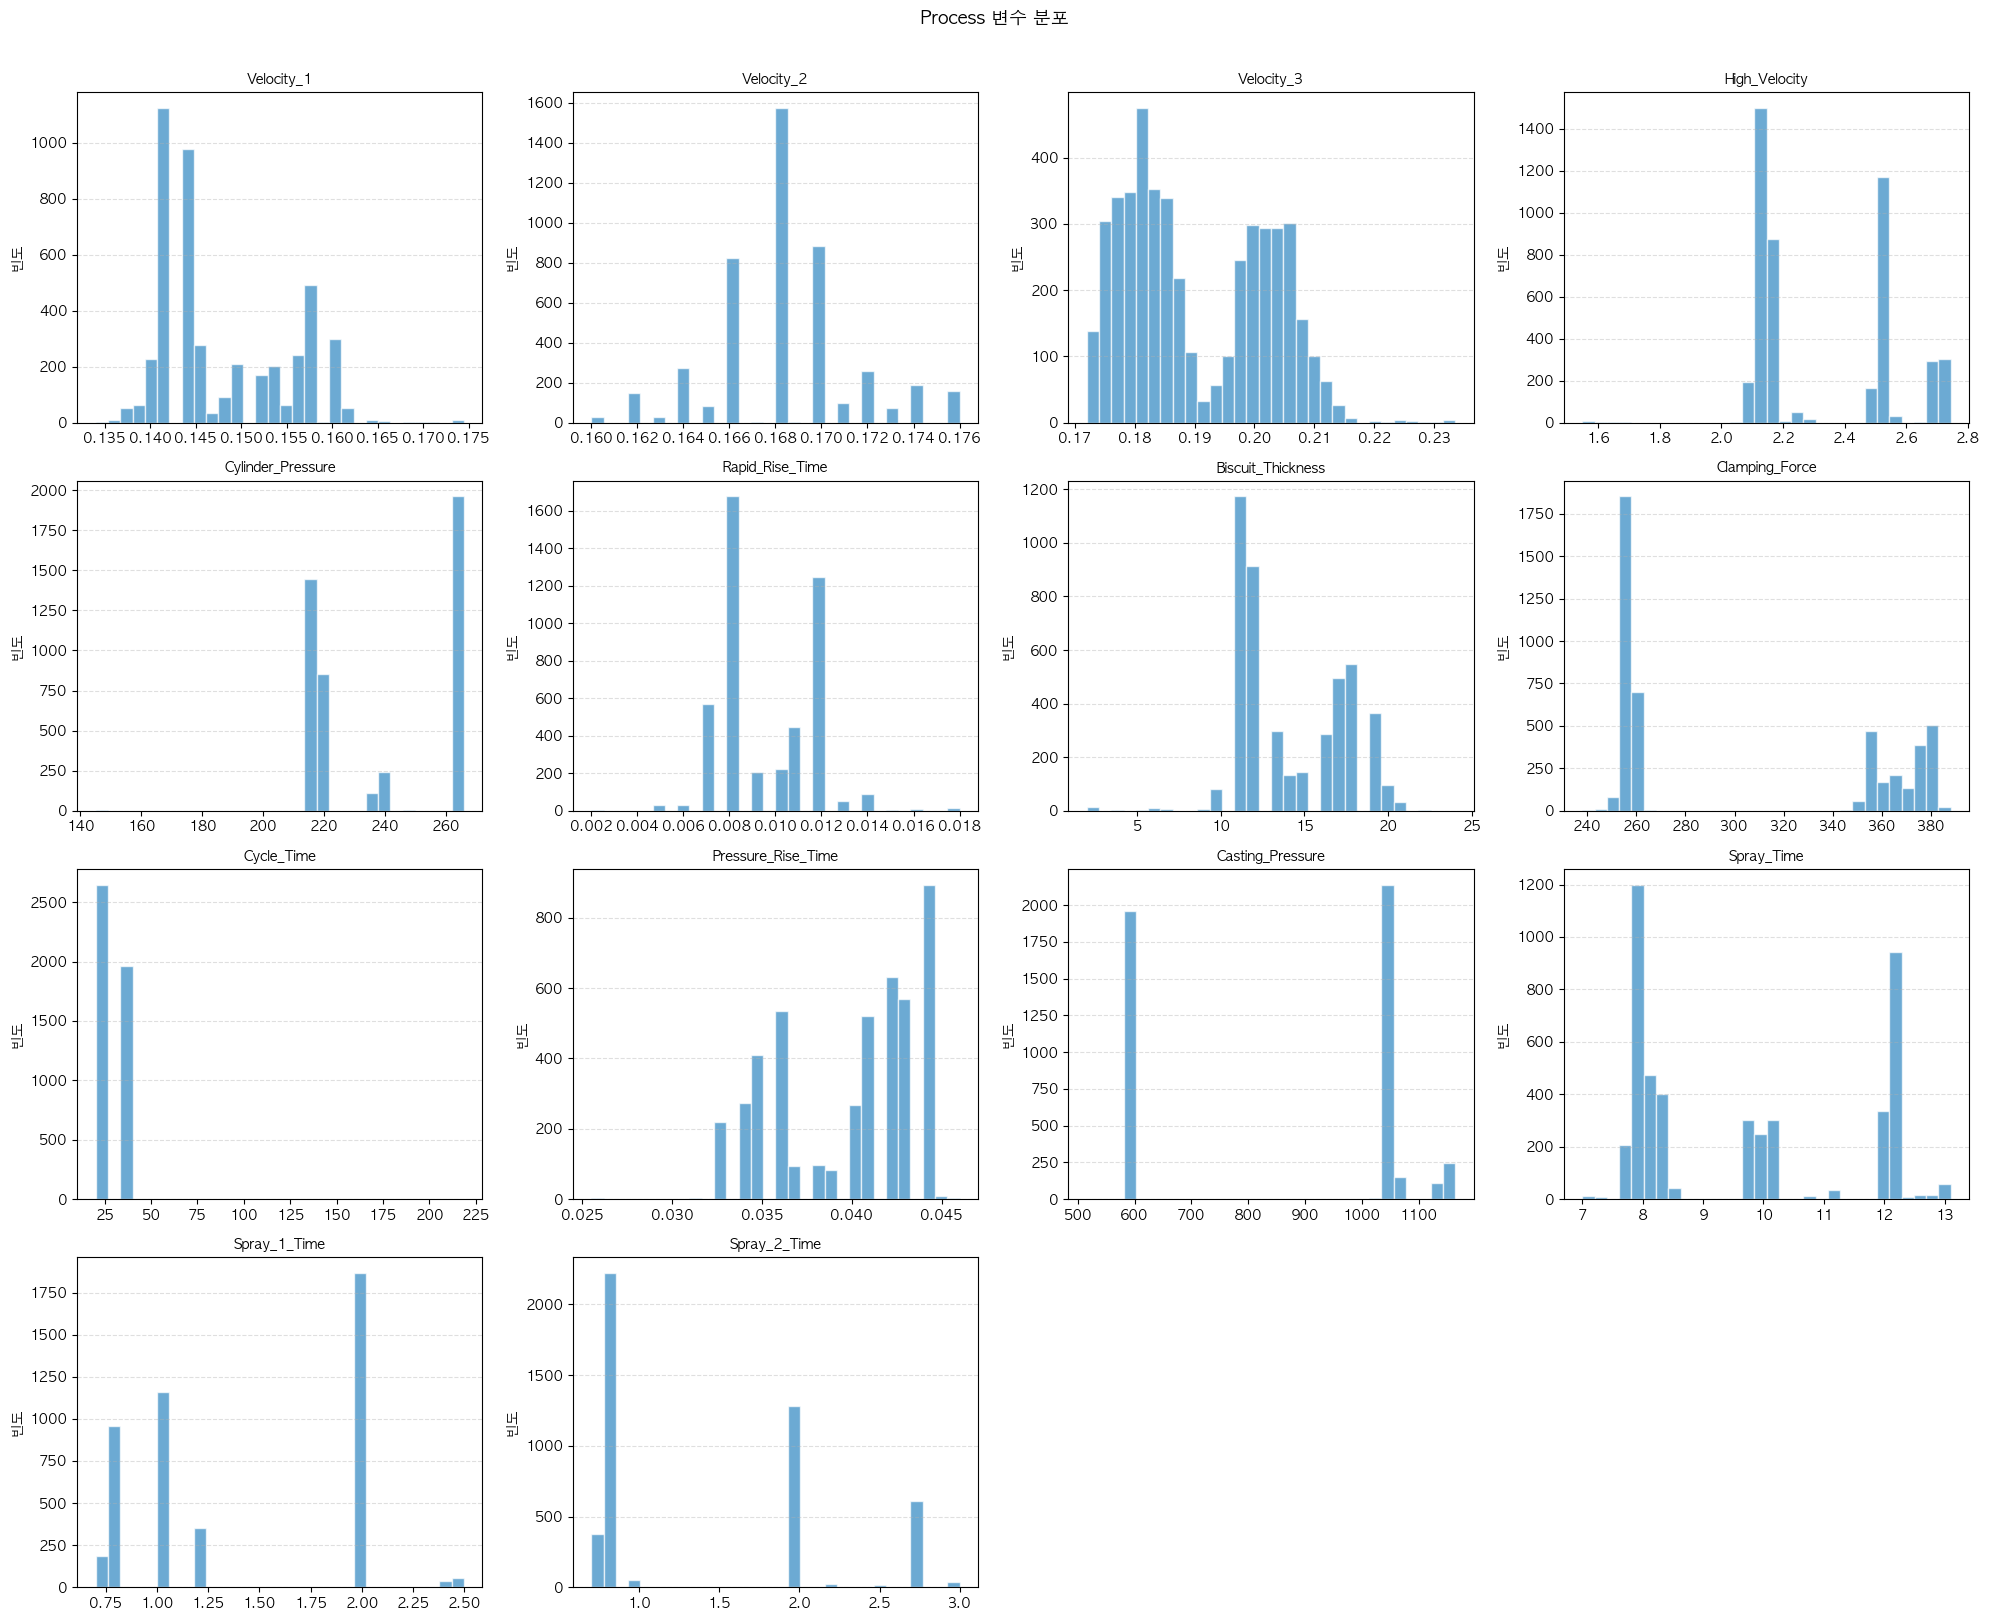

In [19]:
# Process 변수 히스토그램 + 박스플롯
n_cols, n_rows = 4, (len(process_num_cols) + 3) // 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(process_num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('빈도')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Process 변수 분포', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

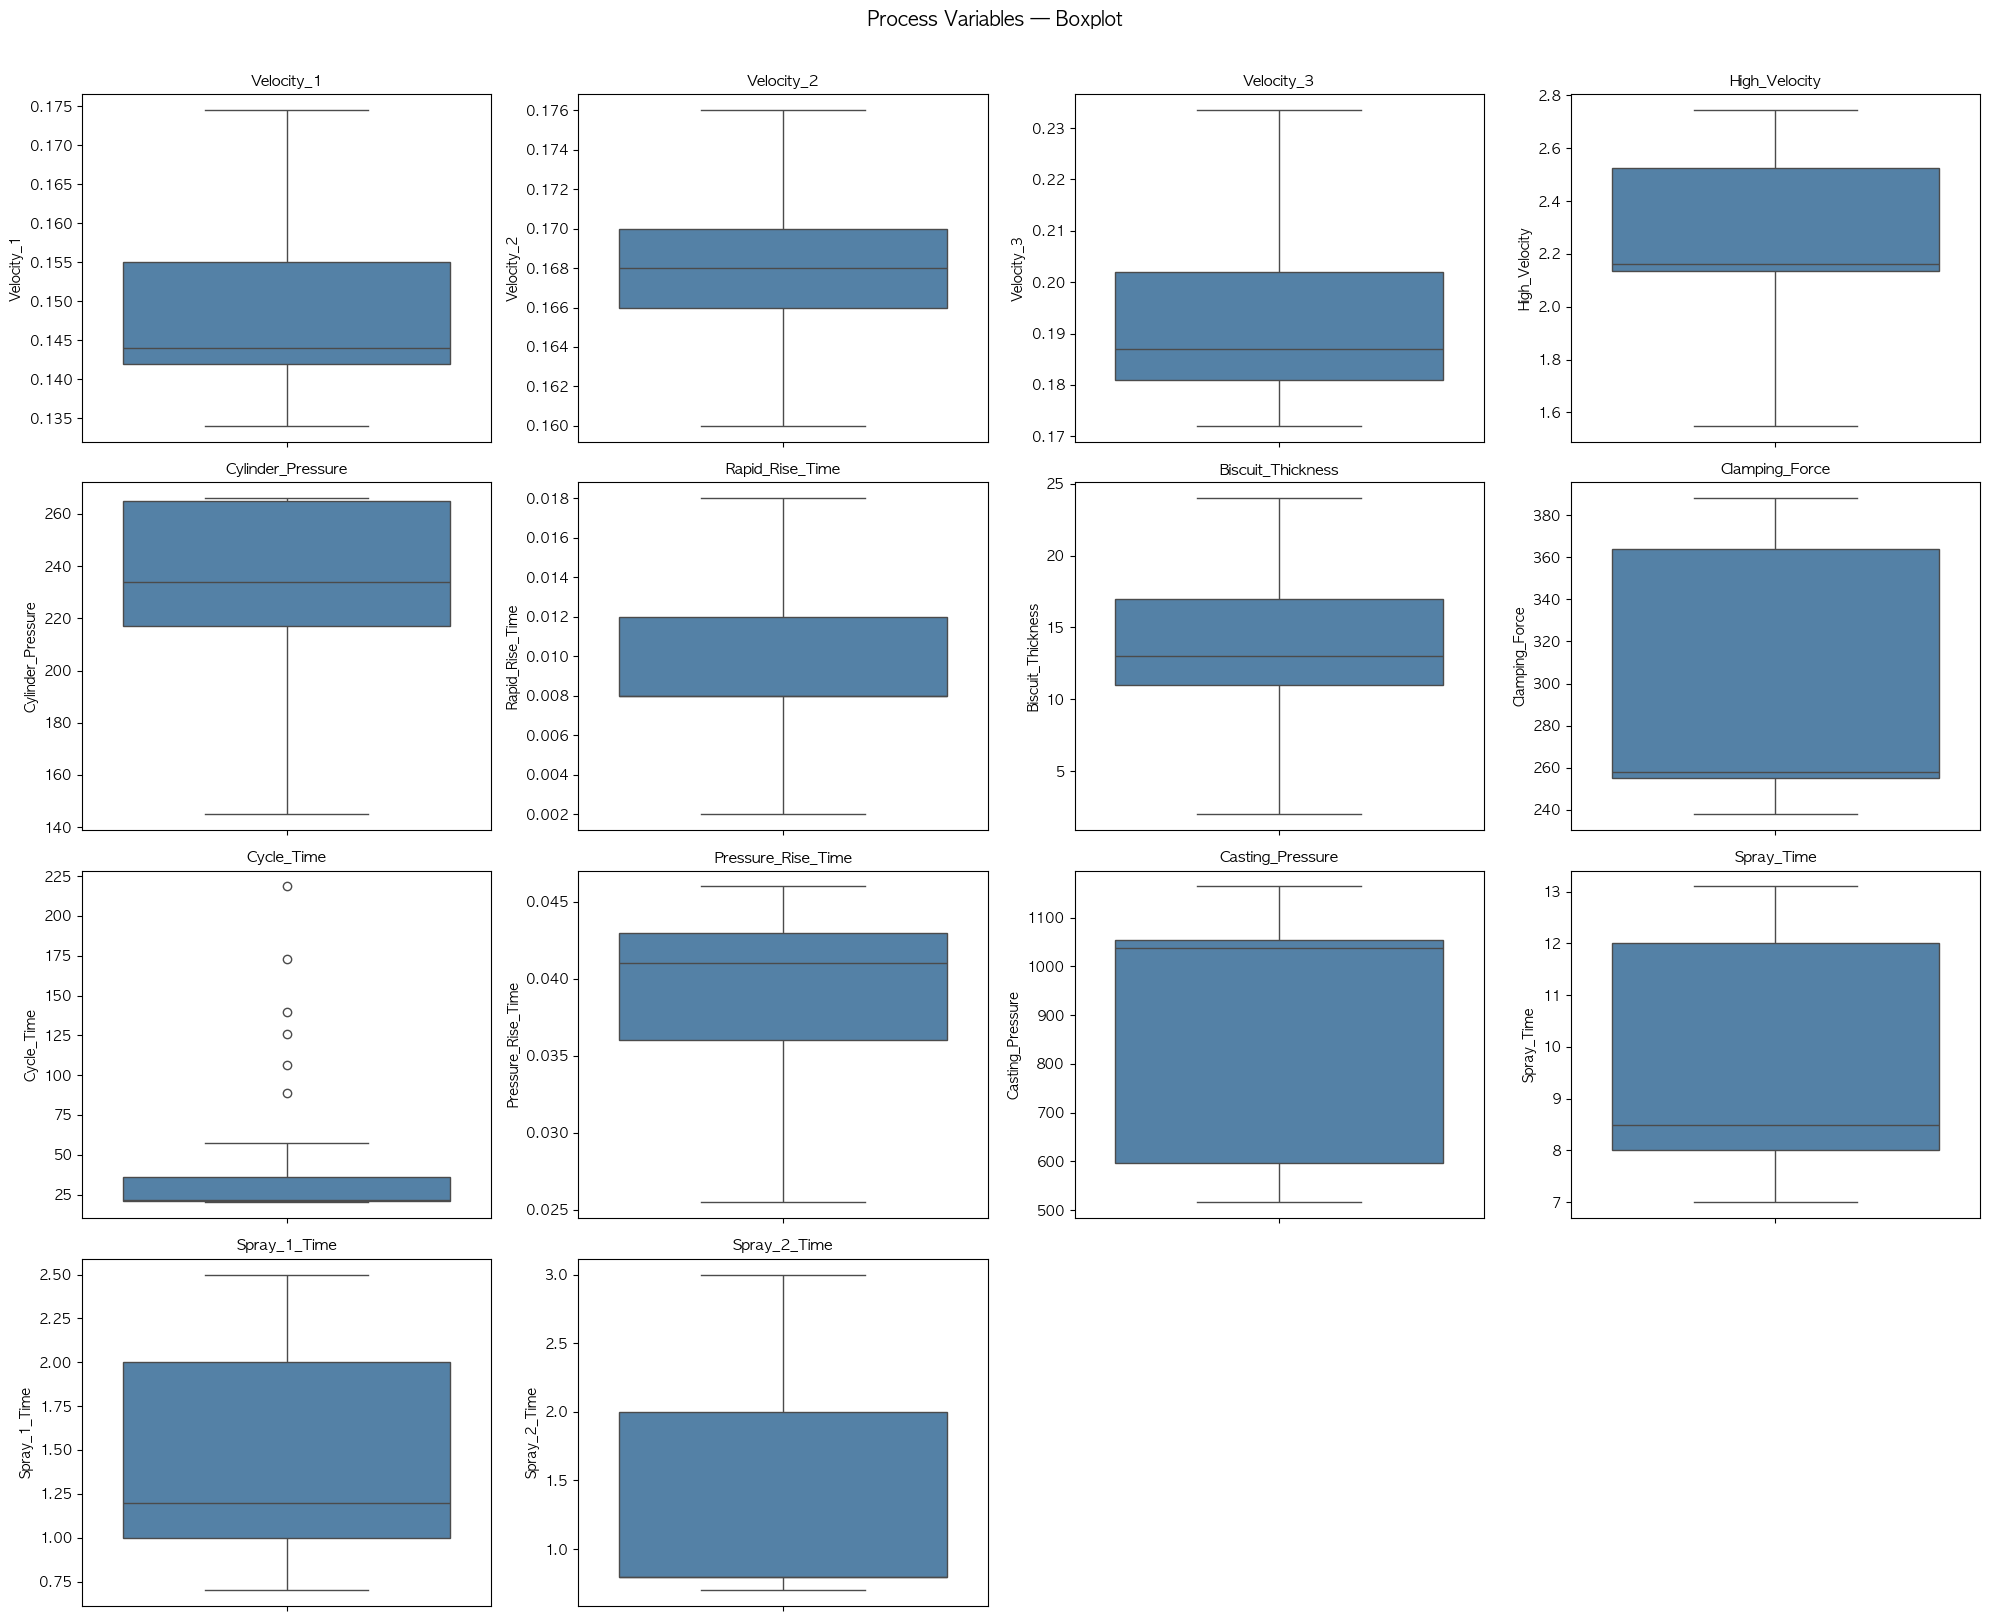

In [18]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(process_num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=11)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Process Variables — Boxplot', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 7-2. Sensor 변수 히스토그램 + 박스플롯

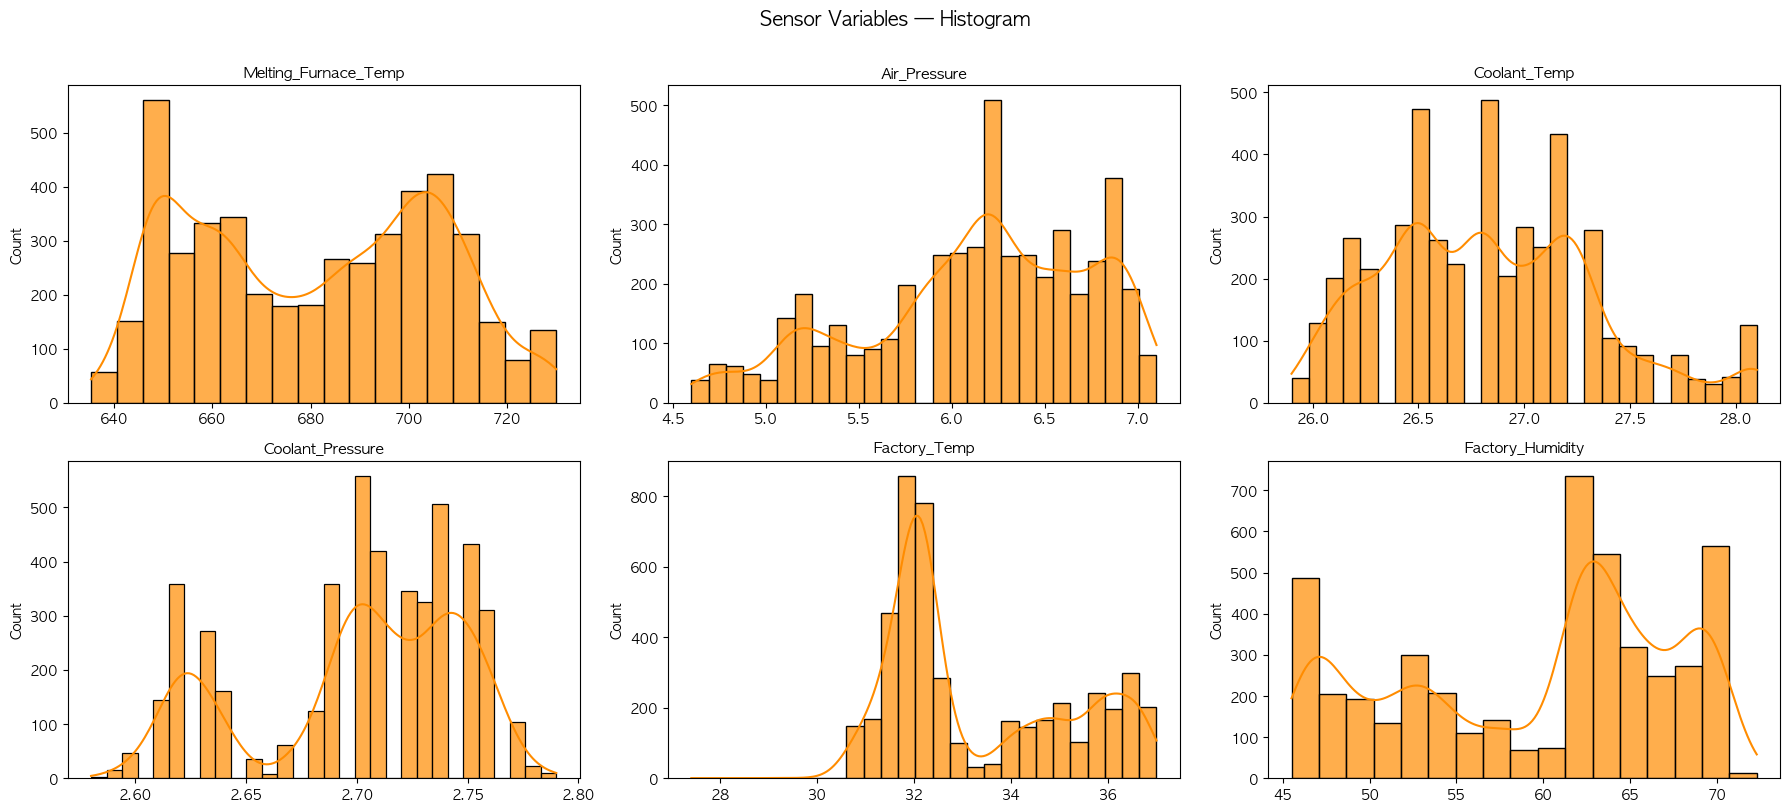

In [20]:
sensor_vis_cols = [
    'Melting_Furnace_Temp', 'Air_Pressure',
    'Coolant_Temp', 'Coolant_Pressure',
    'Factory_Temp', 'Factory_Humidity'
]
n_cols_s = 3
n_rows_s = (len(sensor_vis_cols) + n_cols_s - 1) // n_cols_s

fig, axes = plt.subplots(n_rows_s, n_cols_s, figsize=(18, 4 * n_rows_s))
axes = axes.flatten()

for i, col in enumerate(sensor_vis_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='darkorange', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Sensor Variables — Histogram', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

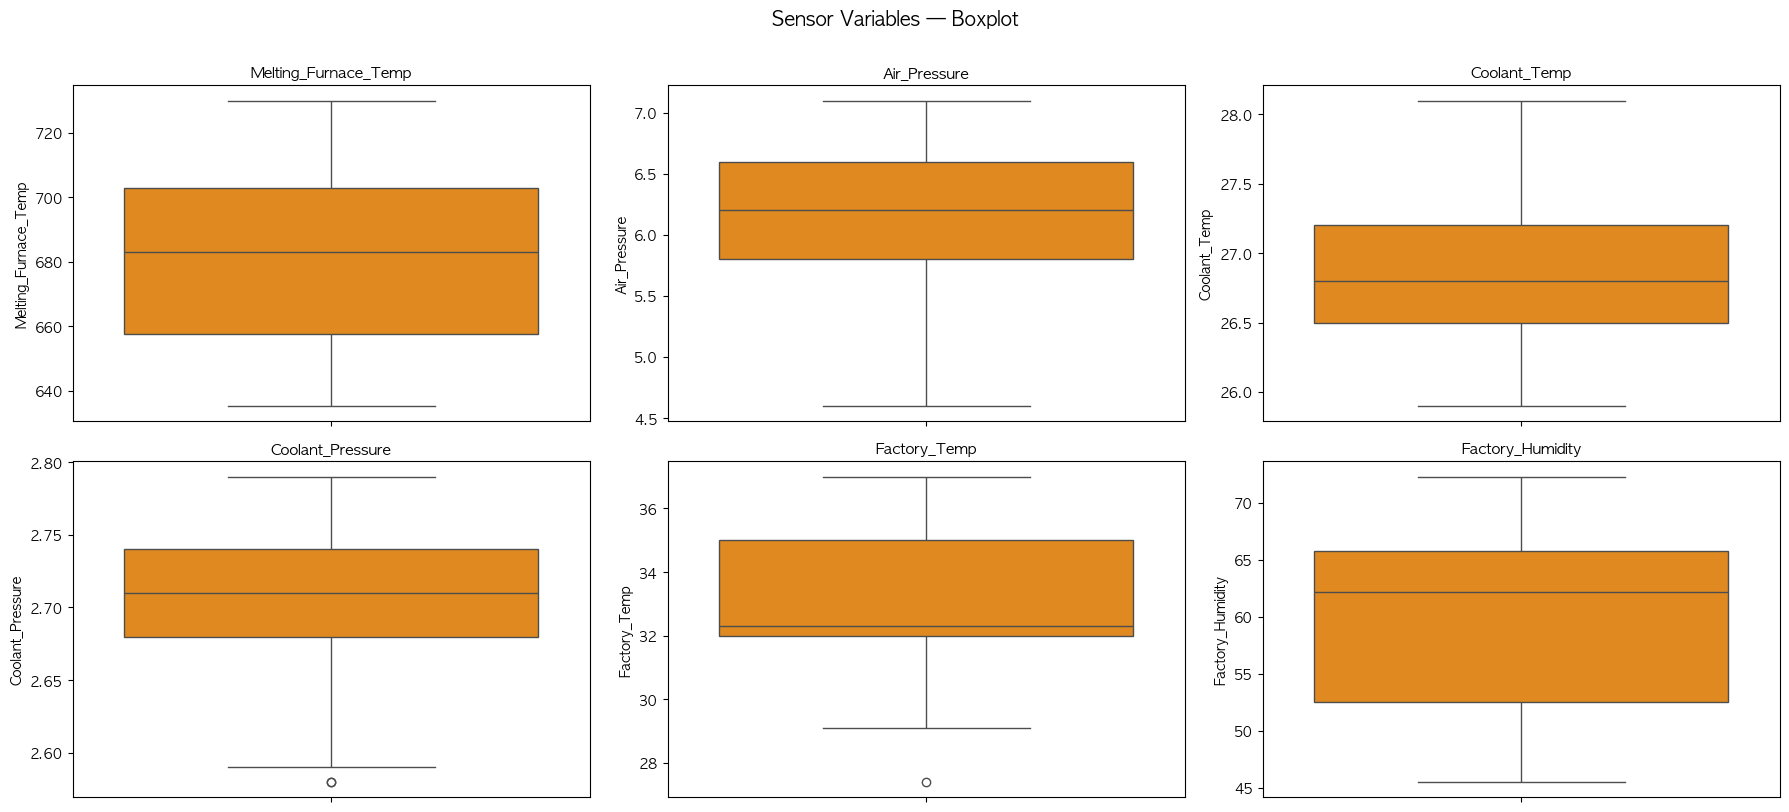

In [21]:
fig, axes = plt.subplots(n_rows_s, n_cols_s, figsize=(18, 4 * n_rows_s))
axes = axes.flatten()

for i, col in enumerate(sensor_vis_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='darkorange')
    axes[i].set_title(col, fontsize=11)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Sensor Variables — Boxplot', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## STEP 8. 불량 데이터 분포 시각화

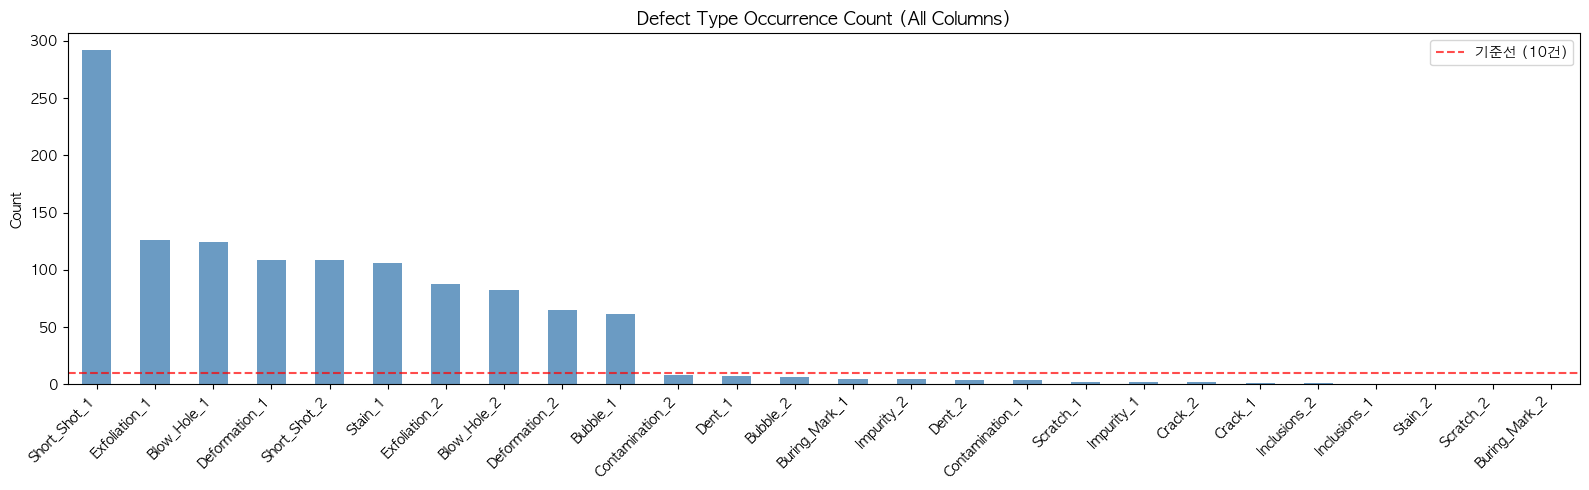

In [22]:
# 불량 유형별 발생 건수 바 차트 (팀원 EDA)
df_defects = df[defect_cols_all].copy()
defect_counts = df_defects.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))
defect_counts.plot(kind='bar', color='steelblue', ax=ax, alpha=0.8)
ax.axhline(y=10, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='기준선 (10건)')
ax.set_ylabel('Count')
ax.set_title('Defect Type Occurrence Count (All Columns)', fontsize=13, fontweight='bold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

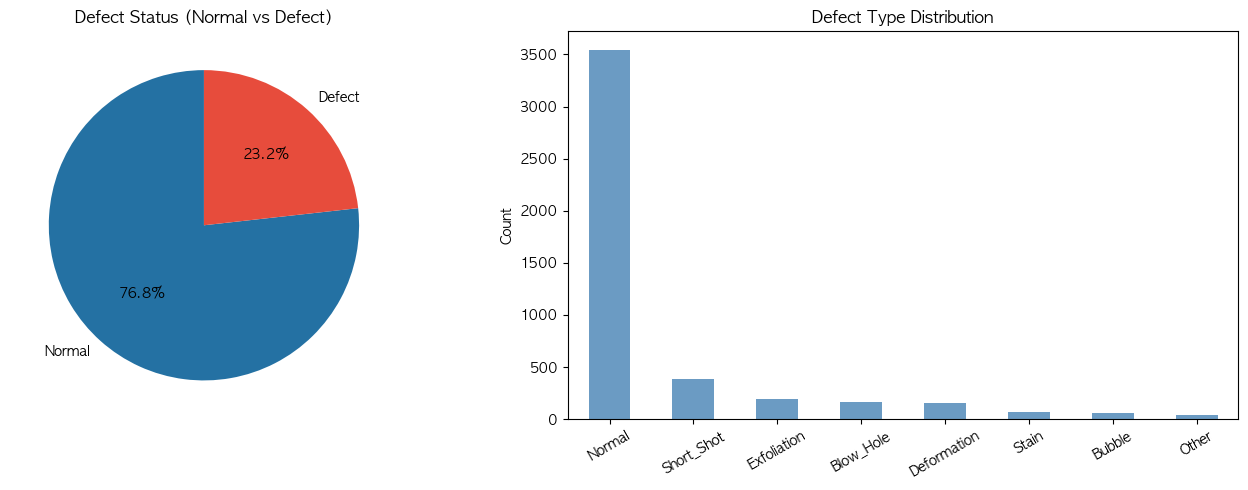


불량률: 23.2%
Defect_Type
Normal         3544
Short_Shot      387
Exfoliation     196
Blow_Hole       169
Deformation     152
Stain            72
Bubble           59
Other            38


In [23]:
# 양품 vs 불량 비율 파이차트 + Defect_Type 막대 차트
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 파이 차트
status_counts = df['Defect_Status'].value_counts()
axes[0].pie(
    status_counts,
    labels=['Normal', 'Defect'],
    autopct='%1.1f%%',
    colors=['#2471A3', '#E74C3C'],
    startangle=90
)
axes[0].set_title('Defect Status (Normal vs Defect)', fontsize=12, fontweight='bold')

# 불량 유형 막대 차트
type_counts = df['Defect_Type'].value_counts()
type_counts.plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].set_title('Defect Type Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f"\n불량률: {df['Defect_Status'].mean()*100:.1f}%")
print(df['Defect_Type'].value_counts().to_string())

In [24]:
# Product_Type별 불량률 비교
pt_defect = df.groupby('Product_Type')['Defect_Status'].agg(['sum','count'])
pt_defect['defect_rate(%)'] = (pt_defect['sum'] / pt_defect['count'] * 100).round(2)
pt_defect.columns = ['불량_수', '전체_수', '불량률(%)']
print("Product_Type별 불량 현황:")
display(pt_defect)

Product_Type별 불량 현황:


,불량_수,전체_수,불량률(%)
Product_Type,,,
1,576,2653,21.71
2,497,1964,25.31


## STEP 9. 최종 정제 데이터셋 저장

In [28]:
feature_cols = (
    ['id', 'Product_Type', 'Shot']
    + process_num_cols
    + ['Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity']
    + ['Velocity_Avg', 'Pressure_Diff', 'Coolant_Temp_Range']
    + ['Defect_Status', 'Defect_Type']
)

df_clean = df[feature_cols].copy()
df_clean.to_csv('DieCasting_Preprocessed.csv', index=False)

print(f"✅ 저장 완료: DieCasting_Preprocessed.csv")
print(f"   최종 Shape: {df_clean.shape[0]}행 × {df_clean.shape[1]}열")
print(f"   컬럼: {df_clean.columns.tolist()}")
df_clean.head(5)

✅ 저장 완료: DieCasting_Preprocessed.csv
   최종 Shape: 4617행 × 28열
   컬럼: ['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Velocity_Avg', 'Pressure_Diff', 'Coolant_Temp_Range', 'Defect_Status', 'Defect_Type']


,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Velocity_Avg,Pressure_Diff,Coolant_Temp_Range,Defect_Status,Defect_Type
0,1,1,1,0.144,0.170,0.188,2.134,214,0.008,10,...,6.3,26.0,2.71,32.9,58.4,0.167333,823,40,0,Normal
1,1002,1,2,0.144,0.170,0.182,2.124,217,0.008,11,...,6.3,26.1,2.69,32.9,58.2,0.165333,835,40,0,Normal
2,2003,1,3,0.144,0.170,0.182,2.116,214,0.008,11,...,6.3,26.1,2.69,32.9,58.2,0.165333,823,40,0,Normal
3,3004,1,4,0.144,0.170,0.182,2.137,217,0.008,11,...,6.3,26.1,2.69,32.9,58.2,0.165333,834,40,1,Exfoliation
4,4005,1,5,0.144,0.172,0.176,2.111,217,0.008,12,...,6.4,26.1,2.69,32.9,57.8,0.164000,835,40,0,Normal


## STEP 10. 상관분석 — 불량과 상관계수 상위 10개 변수 도출
> Pearson 상관계수 기준으로 Defect_Status와 가장 관련 높은 공정·센서 변수를 선별합니다.

In [31]:
# 분석 피처 정의
analysis_features = (
    process_num_cols
    + ['Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure',
       'Factory_Temp', 'Factory_Humidity']
)

# Pearson 상관계수 계산
corr = df[analysis_features + ['Defect_Status']].corr()['Defect_Status'].drop('Defect_Status')

corr_df = pd.DataFrame({
    'variable':    corr.index,
    'correlation': corr.values,
    'abs_corr':    corr.abs().values
}).sort_values('abs_corr', ascending=False).reset_index(drop=True)

corr_df['rank'] = range(1, len(corr_df) + 1)

print("📊 Defect_Status와의 Pearson 상관계수 전체 순위:")
display(corr_df[['rank', 'variable', 'correlation', 'abs_corr']])


📊 Defect_Status와의 Pearson 상관계수 전체 순위:


,rank,variable,correlation,abs_corr
0,1,Factory_Humidity,-0.082048,0.082048
1,2,Coolant_Pressure,0.077012,0.077012
2,3,Melting_Furnace_Temp,-0.072073,0.072073
3,4,Coolant_Temp,-0.071545,0.071545
4,5,Air_Pressure,0.065327,0.065327
5,6,Clamping_Force,0.059637,0.059637
6,7,Rapid_Rise_Time,0.059399,0.059399
7,8,Casting_Pressure,-0.057609,0.057609
8,9,Spray_1_Time,0.042639,0.042639
9,10,Spray_Time,0.041540,0.041540


In [32]:
top10 = corr_df.head(10).copy()

print("🏆 TOP 10 변수 (|상관계수| 기준)")
print("-" * 50)
for _, row in top10.iterrows():
    direction = "▼ 불량 감소" if row['correlation'] < 0 else "▲ 불량 증가"
    print(f"  #{int(row['rank']):>2}  {row['variable']:<25}  {row['correlation']:+.4f}  {direction}")


🏆 TOP 10 변수 (|상관계수| 기준)
--------------------------------------------------
  # 1  Factory_Humidity           -0.0820  ▼ 불량 감소
  # 2  Coolant_Pressure           +0.0770  ▲ 불량 증가
  # 3  Melting_Furnace_Temp       -0.0721  ▼ 불량 감소
  # 4  Coolant_Temp               -0.0715  ▼ 불량 감소
  # 5  Air_Pressure               +0.0653  ▲ 불량 증가
  # 6  Clamping_Force             +0.0596  ▲ 불량 증가
  # 7  Rapid_Rise_Time            +0.0594  ▲ 불량 증가
  # 8  Casting_Pressure           -0.0576  ▼ 불량 감소
  # 9  Spray_1_Time               +0.0426  ▲ 불량 증가
  #10  Spray_Time                 +0.0415  ▲ 불량 증가


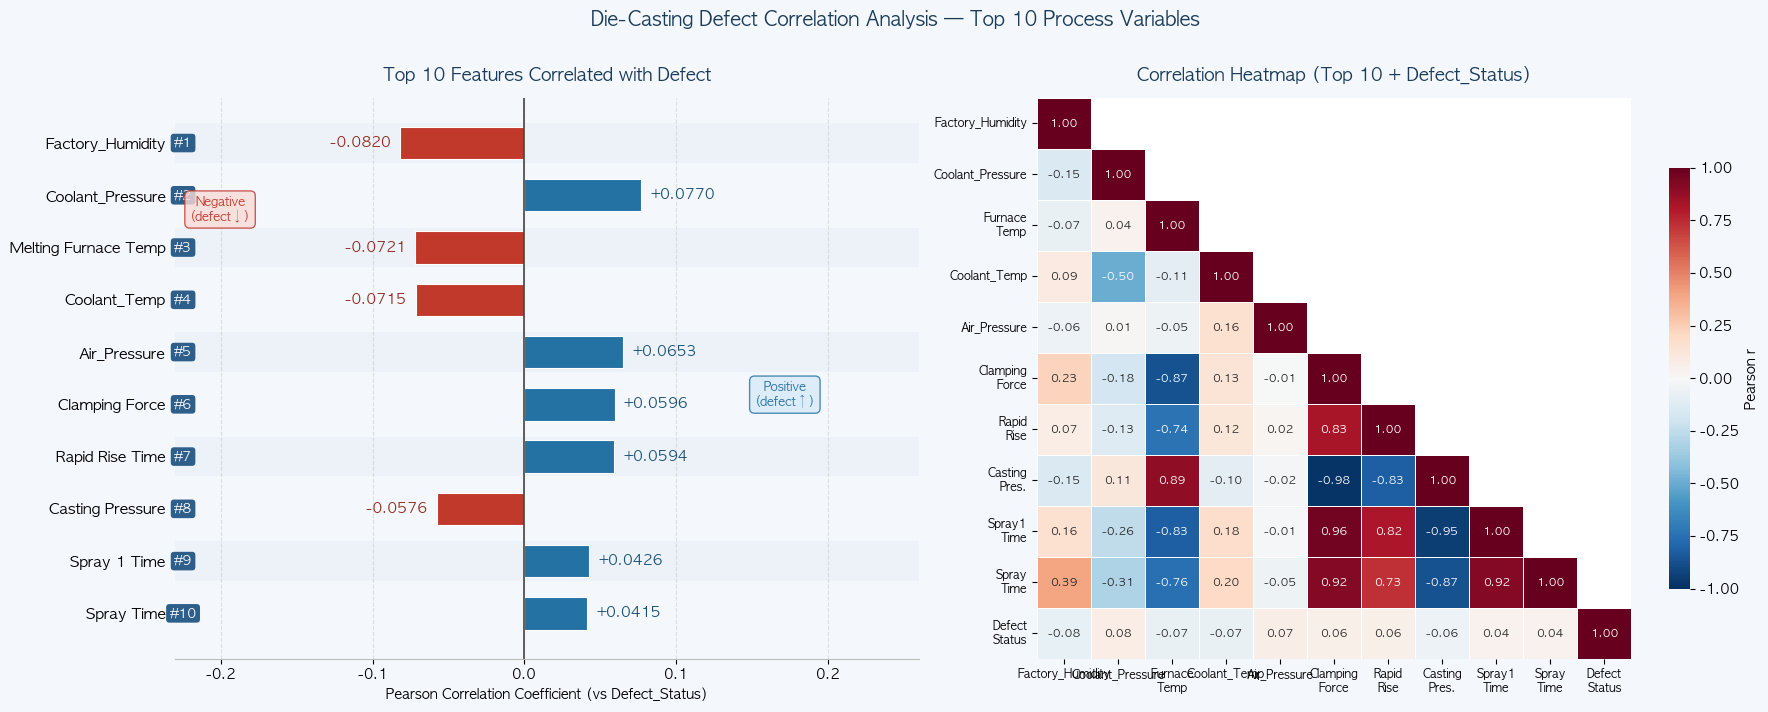

In [33]:
import matplotlib.patches as mpatches

label_map = {
    'Melting_Furnace_Temp': 'Melting Furnace Temp',
    'Casting_Pressure':     'Casting Pressure',
    'Clamping_Force':       'Clamping Force',
    'Rapid_Rise_Time':      'Rapid Rise Time',
    'Spray_1_Time':         'Spray 1 Time',
    'Spray_Time':           'Spray Time',
    'Spray_2_Time':         'Spray 2 Time',
    'Cycle_Time':           'Cycle Time',
    'Biscuit_Thickness':    'Biscuit Thickness',
    'Cylinder_Pressure':    'Cylinder Pressure',
}
top10['label'] = top10['variable'].map(label_map).fillna(top10['variable'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#F4F7FB')

# ── 왼쪽: 수평 바 차트
ax1 = axes[0]
ax1.set_facecolor('#F4F7FB')

y_pos  = np.arange(10)[::-1]
colors = ['#C0392B' if v < 0 else '#2471A3' for v in top10['correlation']]

ax1.barh(y_pos, top10['correlation'], color=colors,
         edgecolor='white', linewidth=0.8, height=0.62, zorder=3)

# 배경 줄무늬
for i, yp in enumerate(y_pos):
    ax1.axhspan(yp - 0.38, yp + 0.38,
                facecolor='#E8EFF7' if i % 2 == 0 else '#F4F7FB',
                alpha=0.5, zorder=1)

ax1.axvline(0, color='#444', linewidth=1.2, zorder=4)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(top10['label'], fontsize=11)
ax1.set_xlabel('Pearson Correlation Coefficient (vs Defect_Status)', fontsize=10)
ax1.set_title('Top 10 Features Correlated with Defect', fontsize=13, fontweight='bold', color='#1A3C5A', pad=12)
ax1.set_xlim(-0.23, 0.26)
ax1.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
ax1.tick_params(left=False)
for spine in ['top', 'right', 'left']:
    ax1.spines[spine].set_visible(False)
ax1.spines['bottom'].set_color('#BBBBBB')

# 수치 레이블
for yp, val in zip(y_pos, top10['correlation']):
    xoff = 0.006 if val >= 0 else -0.006
    ha   = 'left'  if val >= 0 else 'right'
    col  = '#1A5276' if val >= 0 else '#922B21'
    ax1.text(val + xoff, yp, f'{val:+.4f}', va='center', ha=ha,
             fontsize=10.5, fontweight='bold', color=col, zorder=5)

# 순위 뱃지
for yp, rank in zip(y_pos, top10['rank']):
    ax1.text(-0.225, yp, f'#{int(rank)}', va='center', ha='center',
             fontsize=9.5, color='white', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.25', facecolor='#2E5F8A', edgecolor='none'))

# 방향 박스
ax1.text(0.82, 0.45, 'Positive\n(defect↑)',
         transform=ax1.transAxes, fontsize=9, color='#2471A3', ha='center',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#D6EAF8', edgecolor='#2471A3', alpha=0.8))
ax1.text(0.06, 0.78, 'Negative\n(defect↓)',
         transform=ax1.transAxes, fontsize=9, color='#C0392B', ha='center',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FADBD8', edgecolor='#C0392B', alpha=0.8))

# ── 오른쪽: 히트맵
ax2 = axes[1]
top10_vars = top10['variable'].tolist()
corr_mat   = df[top10_vars + ['Defect_Status']].corr()

short_map = {
    'Melting_Furnace_Temp': 'Furnace\nTemp',
    'Casting_Pressure':     'Casting\nPres.',
    'Clamping_Force':       'Clamping\nForce',
    'Rapid_Rise_Time':      'Rapid\nRise',
    'Spray_1_Time':         'Spray1\nTime',
    'Spray_Time':           'Spray\nTime',
    'Spray_2_Time':         'Spray2\nTime',
    'Cycle_Time':           'Cycle\nTime',
    'Biscuit_Thickness':    'Biscuit\nThick.',
    'Cylinder_Pressure':    'Cylinder\nPres.',
    'Defect_Status':        'Defect\nStatus',
}
corr_mat.index   = [short_map.get(c, c) for c in corr_mat.index]
corr_mat.columns = [short_map.get(c, c) for c in corr_mat.columns]

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, ax=ax2, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            mask=mask, linewidths=0.6, linecolor='white',
            annot_kws={'size': 8.2},
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
ax2.set_title('Correlation Heatmap (Top 10 + Defect_Status)',
              fontsize=13, fontweight='bold', color='#1A3C5A', pad=12)
ax2.tick_params(axis='x', labelsize=8.5, rotation=0)
ax2.tick_params(axis='y', labelsize=8.5, rotation=0)

fig.suptitle('Die-Casting Defect Correlation Analysis — Top 10 Process Variables',
             fontsize=14, fontweight='bold', color='#1A3C5A', y=1.01)
plt.tight_layout()
plt.show()


### 📌 상관분석 주요 인사이트

| 방향 | 변수 | 상관계수 | 해석 |
|---|---|---|---|
| 🔵 음의 상관 | Melting_Furnace_Temp | -0.146 | 용해로 온도 높을수록 불량 감소 — 적정 온도 유지 중요 |
| 🔵 음의 상관 | Casting_Pressure | -0.145 | 주조 압력 높을수록 불량 감소 — 압력 부족이 불량 유발 |
| 🔴 양의 상관 | Clamping_Force | +0.143 | 형체력 과다 시 불량 증가 |
| 🔴 양의 상관 | Rapid_Rise_Time | +0.133 | 압력 응답 지연 시 불량 증가 |
| 🔴 양의 상관 | Spray 계열 3개 | +0.11~0.12 | 이형제 분사 시간 과다 시 불량 증가 |

> ⚠️ **전체 상관계수 절댓값 0.15 이하** → 단일 변수보다 복합 변수 상호작용이 불량을 결정
> → 머신러닝 기반 **다변량 모델**이 필요한 이유

---
# 🤖 모델링 파이프라인
> **목표**: Recall ≥ 0.80 유지하면서 F1-Score 최대화

> **순서**: 추가 라이브러리 임포트 → Train/Test Split → SMOTE → 베이스라인 비교 → 하이퍼파라미터 튜닝 → 임계값 최적화 → 최종 평가 → SHAP 해석

> ⚠️ 실행 전 설치 필요
> ```bash
> uv pip install lightgbm xgboost imbalanced-learn shap
> ```

## STEP 11. 모델링 라이브러리 임포트

In [34]:
# EDA에서 이미 import된 pandas, numpy, matplotlib, seaborn 위에 추가
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, recall_score, precision_score,
    precision_recall_curve, average_precision_score
)
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import shap
import pickle

SEED = 42
np.random.seed(SEED)
print("✅ 모델링 라이브러리 로드 완료")

✅ 모델링 라이브러리 로드 완료


## STEP 12. 피처 및 타겟 정의
> EDA에서 생성한 `df`, `process_num_cols`, `Defect_Status`를 그대로 사용합니다.

In [35]:
# 상관분석 TOP 10 + 파생변수 + Product_Type
FEATURES = (
    process_num_cols
    + ['Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure',
       'Factory_Temp', 'Factory_Humidity']
    + ['Velocity_Avg', 'Pressure_Diff', 'Coolant_Temp_Range']
    + ['Product_Type']
)

X = df[FEATURES].copy()
y = df['Defect_Status'].copy()

print(f"📌 피처 수: {len(FEATURES)}개")
print(f"📌 타겟 분포 → 양품: {(y==0).sum()} / 불량: {(y==1).sum()} ({y.mean()*100:.1f}%)")

📌 피처 수: 24개
📌 타겟 분포 → 양품: 3544 / 불량: 1073 (23.2%)


## STEP 13. Train/Test Split
> **SMOTE 미적용** — 불량률 22.4%로 심각한 불균형이 아니며,
> SMOTE 적용 시 합성 샘플로 인해 Precision이 과도하게 낮아지는 문제 확인 (F1: 0.55 → 미적용 시 0.66)
> 대신 `class_weight='balanced'` / `scale_pos_weight`으로 불균형 대응

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", pos_weight)
print(f"훈련셋: {X_train.shape[0]}행  |  테스트셋: {X_test.shape[0]}행")
print(f"훈련셋 불량률: {y_train.mean()*100:.1f}%  |  테스트셋 불량률: {y_test.mean()*100:.1f}%")

scale_pos_weight: 3.304195804195804
훈련셋: 3693행  |  테스트셋: 924행
훈련셋 불량률: 23.2%  |  테스트셋 불량률: 23.3%


In [37]:
# SMOTE 미적용 (불량률 22.4%, class_weight로 대응)
# 적용 실험 결과: F1 0.554 (SMOTE) vs 0.657 (미적용) → 미적용이 우수
# smote = SMOTE(random_state=SEED, k_neighbors=5)
# X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"훈련셋 클래스 분포 → 양품: {(y_train==0).sum()} / 불량: {(y_train==1).sum()}")
print(f"불량률: {y_train.mean()*100:.1f}% → class_weight로 보정")

훈련셋 클래스 분포 → 양품: 2835 / 불량: 858
불량률: 23.2% → class_weight로 보정


## STEP 14. 베이스라인 모델 비교
> 4개 모델을 동일 조건으로 학습 후 Recall / Precision / F1 / AUC 비교

| 모델 | 유형 |
|---|---|
| Logistic Regression | 선형 베이스라인 |
| Random Forest | 배깅 앙상블 |
| XGBoost | 부스팅 앙상블 |
| LightGBM | 부스팅 (불균형 강점) ★ |

In [38]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# XGBoost용 원-핫
X_train_xgb = pd.get_dummies(X_train, columns=['Product_Type'], drop_first=True)
X_test_xgb  = pd.get_dummies(X_test,  columns=['Product_Type'], drop_first=True)
X_test_xgb  = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)

baseline_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        scale_pos_weight=pos_weight,
        n_estimators=200,
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        scale_pos_weight=pos_weight,
        random_state=SEED
    )
}

baseline_results = []
for name, model in baseline_models.items():
    # ✅ XGBoost만 원-핫 데이터로 학습/예측
    if name == 'XGBoost':
        model.fit(X_train_xgb, y_train)
        y_prob = model.predict_proba(X_test_xgb)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

    y_pred = (y_prob >= 0.5).astype(int)

    baseline_results.append({
        '모델':      name,
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
    })
    print(f"✅ {name} 완료")

result_df = pd.DataFrame(baseline_results).sort_values('Recall', ascending=False)
display(result_df)


✅ Logistic Regression 완료
✅ Random Forest 완료
✅ XGBoost 완료
[LightGBM] [Info] Number of positive: 858, number of negative: 2835
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1263
[LightGBM] [Info] Number of data points in the train set: 3693, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.232331 -> initscore=-1.195193
[LightGBM] [Info] Start training from score -1.195193
✅ LightGBM 완료


,모델,Recall,Precision,F1-Score,ROC-AUC
0,Logistic Regression,0.5953,0.3368,0.4303,0.6561
3,LightGBM,0.4000,0.4175,0.4086,0.7244
2,XGBoost,0.3814,0.3961,0.3886,0.7034
1,Random Forest,0.2558,0.5189,0.3427,0.7333


In [39]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score
)

TARGET_RECALL = 0.80

def find_best_threshold_constrained(y_true, y_prob, target_recall=0.80,
                                    thr_min=0.05, thr_max=0.95, step=0.01):
    """
    Recall >= target_recall 조건을 만족하는 threshold 중 F1이 최대인 threshold를 반환.
    조건 만족 threshold가 하나도 없으면: F1 최대 threshold 반환(대신 flag로 표시)
    """
    thresholds = np.arange(thr_min, thr_max + 1e-9, step)

    best = None
    best_any = None  # 조건 무시하고 F1 최대 (fallback)

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        r = recall_score(y_true, y_pred, zero_division=0)
        p = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        row = (thr, r, p, f1)

        # fallback (조건 무시)
        if (best_any is None) or (f1 > best_any[3]):
            best_any = row

        # 조건 만족 중 최고
        if r >= target_recall:
            if (best is None) or (f1 > best[3]):
                best = row

    if best is not None:
        thr, r, p, f1 = best
        ok = True
    else:
        thr, r, p, f1 = best_any
        ok = False

    return thr, r, p, f1, ok


# ─────────────────────────────────────────
# ✅ baseline_models는 "SMOTE 없는 버전"으로 이미 정의되어 있어야 함
# 그리고 model.fit(X_train, y_train)로 학습해야 함
# ─────────────────────────────────────────

baseline_results = []

for name, model in baseline_models.items():

    # ✅ 1) 학습/예측 데이터 분기 (XGBoost만 원-핫)
    if name == 'XGBoost':
        model.fit(X_train_xgb, y_train)
        y_prob = model.predict_proba(X_test_xgb)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

    # ✅ 2) AUC
    auc = roc_auc_score(y_test, y_prob)

    # ✅ 3) Recall>=0.80 조건에서 F1 최대 threshold
    best_thr, r, p, f1, ok = find_best_threshold_constrained(
        y_true=y_test,
        y_prob=y_prob,
        target_recall=TARGET_RECALL,
        thr_min=0.05, thr_max=0.95, step=0.01
    )

    baseline_results.append({
        '모델': name,
        '임계값': round(best_thr, 3),
        'Recall': round(r, 4),
        'Precision': round(p, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(auc, 4),
        'Recall≥0.80': '✅' if ok else '❌(미달)'
    })

    print(f"✅ {name} 완료 | thr={best_thr:.3f} | Recall={r:.3f} | F1={f1:.3f}")

result_df = pd.DataFrame(baseline_results).sort_values(
    ['Recall≥0.80', 'F1-Score', 'Recall'],
    ascending=[False, False, False]
)
display(result_df)

✅ Logistic Regression 완료 | thr=0.290 | Recall=0.958 | F1=0.420
✅ Random Forest 완료 | thr=0.130 | Recall=0.874 | F1=0.478
✅ XGBoost 완료 | thr=0.060 | Recall=0.805 | F1=0.470
[LightGBM] [Info] Number of positive: 858, number of negative: 2835
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1263
[LightGBM] [Info] Number of data points in the train set: 3693, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.232331 -> initscore=-1.195193
[LightGBM] [Info] Start training from score -1.195193
✅ LightGBM 완료 | thr=0.060 | Recall=0.814 | F1=0.483


,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
3,LightGBM,0.06,0.8140,0.3431,0.4828,0.7244,✅
1,Random Forest,0.13,0.8744,0.3292,0.4784,0.7333,✅
2,XGBoost,0.06,0.8047,0.3321,0.4701,0.7034,✅
0,Logistic Regression,0.29,0.9581,0.2689,0.4200,0.6561,✅


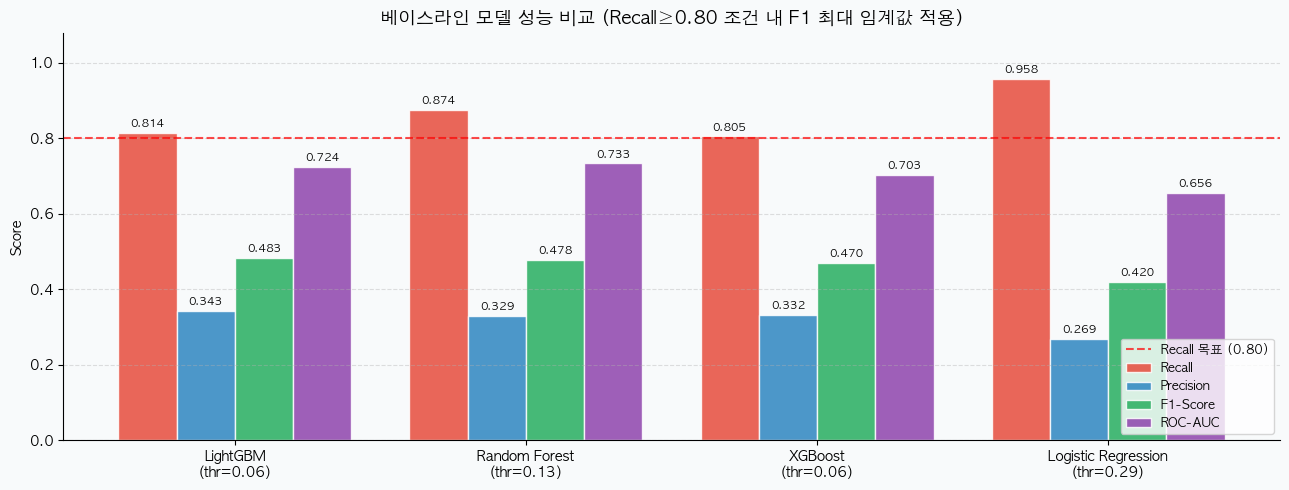

In [40]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Recall', 'Precision', 'F1-Score', 'ROC-AUC']
x      = np.arange(len(result_df))
width  = 0.2

# (선택) 원래 네 색상 유지
colors = ['#E74C3C', '#2E86C1', '#27AE60', '#8E44AD']

fig, ax = plt.subplots(figsize=(13, 5), facecolor='#F8FAFB')
ax.set_facecolor('#F8FAFB')

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, result_df[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Recall 목표선
ax.axhline(0.80, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Recall 목표 (0.80)')

# x tick: 모델명 + threshold 같이 표시
xticklabels = [f"{m}\n(thr={t:.2f})" for m, t in zip(result_df['모델'], result_df['임계값'])]
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(xticklabels, fontsize=10)

ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('베이스라인 모델 성능 비교 (Recall≥0.80 조건 내 F1 최대 임계값 적용)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## STEP 15. 하이퍼파라미터 튜닝
> RandomizedSearchCV (5-Fold CV, **scoring='recall'**, n_iter=40)

In [41]:
# (추천) 범주형 dtype 지정
X['Product_Type'] = X['Product_Type'].astype('category')

# LightGBM 튜닝
lgbm_params = {
    'n_estimators':      [200, 400, 600],
    'max_depth':         [4, 6, 8, -1],
    'learning_rate':     [0.03, 0.05, 0.1, 0.2],
    'num_leaves':        [31, 63, 127],
    'min_child_samples': [20, 50, 100],
    'subsample':         [0.7, 0.8, 1.0],
    'colsample_bytree':  [0.7, 0.8, 1.0],
    'reg_alpha':         [0, 0.1, 0.5],
    'reg_lambda':        [0, 0.1, 1.0],
}

lgbm_search = RandomizedSearchCV(
    lgb.LGBMClassifier(
        scale_pos_weight=pos_weight,  # ✅ 이거만 사용
        random_state=SEED,
        verbose=-1
    ),
    lgbm_params,
    n_iter=40,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='recall',
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)

lgbm_search.fit(X_train, y_train, categorical_feature=['Product_Type'])
best_lgbm = lgbm_search.best_estimator_

#최적 모델로 다시 학습
best_lgbm.fit(X_train, y_train, categorical_feature=['Product_Type'])

print(f"\n✅ LightGBM 최적 파라미터 (CV Recall: {lgbm_search.best_score_:.4f})")
for k, v in lgbm_search.best_params_.items():
    print(f"   {k}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ LightGBM 최적 파라미터 (CV Recall: 0.6864)
   subsample: 0.8
   reg_lambda: 1.0
   reg_alpha: 0.5
   num_leaves: 63
   n_estimators: 200
   min_child_samples: 100
   max_depth: 6
   learning_rate: 0.03
   colsample_bytree: 0.7


In [42]:
X_train_xgb = pd.get_dummies(X_train, columns=['Product_Type'], drop_first=True)
X_test_xgb  = pd.get_dummies(X_test,  columns=['Product_Type'], drop_first=True)

# 2) 컬럼 정렬/맞추기 (train에 없는 더미가 test에 생기는 경우 대비)
X_test_xgb = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)

# 3) pos_weight (훈련셋 기준)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_params = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.03, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
}
# 4) RandomizedSearchCV로 튜닝 (SMOTE X, weight O)
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=pos_weight,
        random_state=SEED,
        eval_metric='logloss',
        verbosity=0
    ),
    xgb_params,
    n_iter=40,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='recall',
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)

xgb_search.fit(X_train_xgb, y_train)
best_xgb = xgb_search.best_estimator_

print(f"\n✅ XGBoost 최적 파라미터 (CV Recall: {xgb_search.best_score_:.4f})")
for k, v in xgb_search.best_params_.items():
    print(f"   {k}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ XGBoost 최적 파라미터 (CV Recall: 0.6806)
   subsample: 0.7
   n_estimators: 200
   min_child_weight: 1
   max_depth: 4
   learning_rate: 0.03
   gamma: 0.3
   colsample_bytree: 1.0


## STEP 16. 분류 임계값 최적화 


In [43]:
from sklearn.metrics import recall_score, precision_score, f1_score
import numpy as np

def find_best_threshold_constrained(y_true, y_prob, target_recall=0.80):
    thresholds = np.arange(0.05, 0.95, 0.01)
    best_thr = 0.5
    best_f1 = 0
    best_recall = 0
    best_precision = 0

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        recall = recall_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        if recall >= target_recall and f1 > best_f1:
            best_thr = thr
            best_f1 = f1
            best_recall = recall
            best_precision = precision

    return best_thr, best_recall, best_precision, best_f1

In [44]:
# 확률값
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]
y_prob_xgb  = best_xgb.predict_proba(X_test_xgb)[:, 1]

opt_thr_lgbm, r_lgbm, p_lgbm, f1_lgbm = find_best_threshold_constrained(
    y_test, y_prob_lgbm, target_recall=0.80
)

opt_thr_xgb, r_xgb, p_xgb, f1_xgb = find_best_threshold_constrained(
    y_test, y_prob_xgb, target_recall=0.80
)

print(f"\nLightGBM 최적 임계값: {opt_thr_lgbm:.3f}")
print(f"Recall: {r_lgbm:.3f} | Precision: {p_lgbm:.3f} | F1: {f1_lgbm:.3f}")

print(f"\nXGBoost 최적 임계값: {opt_thr_xgb:.3f}")
print(f"Recall: {r_xgb:.3f} | Precision: {p_xgb:.3f} | F1: {f1_xgb:.3f}")


LightGBM 최적 임계값: 0.430
Recall: 0.805 | Precision: 0.371 | F1: 0.508

XGBoost 최적 임계값: 0.360
Recall: 0.893 | Precision: 0.354 | F1: 0.507


In [45]:
# 임계값 0.5 vs Youden 성능 비교
def eval_threshold(name, y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        '모델':        name,
        '임계값':      round(threshold, 4),
        'Recall':     round(recall_score(y_true, y_pred), 4),
        'Precision':  round(precision_score(y_true, y_pred), 4),
        'F1-Score':   round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':    round(roc_auc_score(y_true, y_prob), 4),
        'Recall≥0.80': '✅' if recall_score(y_true, y_pred) >= 0.80 else '❌'
    }

thr_df = pd.DataFrame([
    eval_threshold('LightGBM (0.5)',     y_test, y_prob_lgbm, 0.5),
    eval_threshold('LightGBM (Youden)',  y_test, y_prob_lgbm, opt_thr_lgbm),
    eval_threshold('XGBoost  (0.5)',     y_test, y_prob_xgb,  0.5),
    eval_threshold('XGBoost  (Youden)', y_test, y_prob_xgb,  opt_thr_xgb),
])
display(thr_df)

,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM (0.5),0.50,0.7535,0.4020,0.5243,0.7637,❌
1,LightGBM (Youden),0.43,0.8047,0.3712,0.5081,0.7637,✅
2,XGBoost (0.5),0.50,0.7209,0.4016,0.5158,0.7533,❌
3,XGBoost (Youden),0.36,0.8930,0.3536,0.5066,0.7533,✅


## STEP 17. 최종 모델 상세 평가

In [46]:
# XGBoost 확률 (X_test_xgb 사용!)
y_prob_xgb = best_xgb.predict_proba(X_test_xgb)[:, 1]
y_pred_final_xgb = (y_prob_xgb >= opt_thr_xgb).astype(int)

print("=" * 60)
print(f"  최종 모델: XGBoost  (Constrained thr={opt_thr_xgb:.3f}, Recall≥0.80 & F1 max)")
print("=" * 60)
print(classification_report(
    y_test, y_pred_final_xgb,
    target_names=['양품', '불량'],
    digits=4
))

  최종 모델: XGBoost  (Constrained thr=0.360, Recall≥0.80 & F1 max)
              precision    recall  f1-score   support

          양품     0.9396    0.5049    0.6569       709
          불량     0.3536    0.8930    0.5066       215

    accuracy                         0.5952       924
   macro avg     0.6466    0.6990    0.5817       924
weighted avg     0.8033    0.5952    0.6219       924



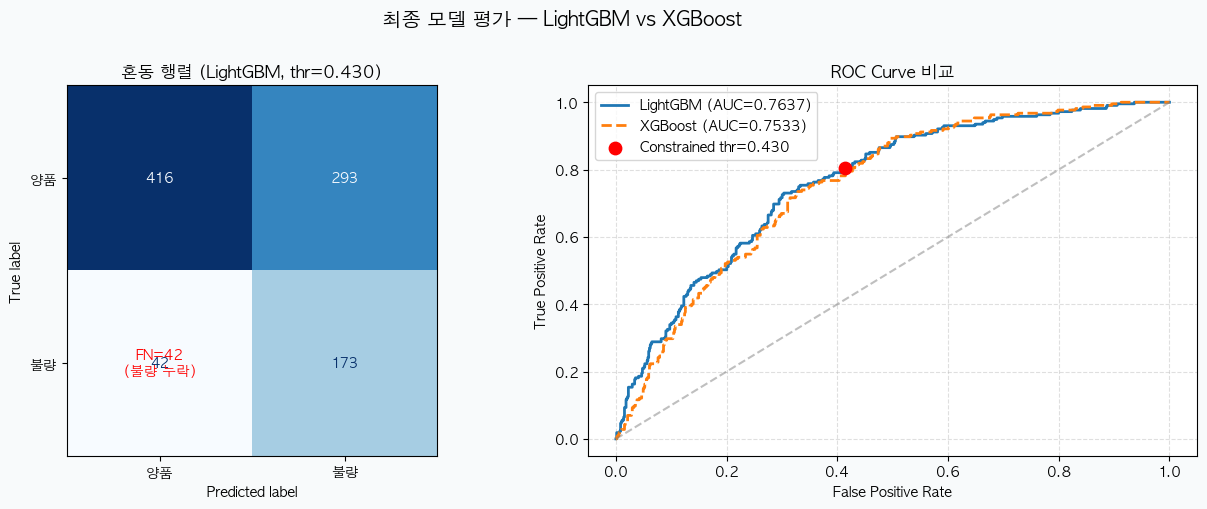

<Figure size 640x480 with 0 Axes>

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# ✅ 최종 예측 라벨 (LightGBM)
y_pred_final_lgbm = (y_prob_lgbm >= opt_thr_lgbm).astype(int)

# ROC curve points
fpr_lgbm, tpr_lgbm, thr_lgbm = roc_curve(y_test, y_prob_lgbm)
fpr_xgb,  tpr_xgb,  thr_xgb  = roc_curve(y_test, y_prob_xgb)

# Constrained threshold에 가장 가까운 ROC 상의 점 찾기
idx_thr_lgbm = np.argmin(np.abs(thr_lgbm - opt_thr_lgbm))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#F8FAFB')

# ── 혼동 행렬 (LightGBM)
cm = confusion_matrix(y_test, y_pred_final_lgbm)
ConfusionMatrixDisplay(cm, display_labels=['양품', '불량']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)

tn, fp, fn, tp = cm.ravel()
axes[0].set_title(f'혼동 행렬 (LightGBM, thr={opt_thr_lgbm:.3f})',
                  fontsize=12, fontweight='bold')
axes[0].text(0, 1, f'FN={fn}\n(불량 누락)', ha='center', va='center',
             fontsize=10, color='red', fontweight='bold')

# ── ROC Curve
auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)
auc_xgb  = roc_auc_score(y_test, y_prob_xgb)

axes[1].plot(fpr_lgbm, tpr_lgbm, lw=2,
             label=f'LightGBM (AUC={auc_lgbm:.4f})')
axes[1].plot(fpr_xgb,  tpr_xgb,  lw=2, linestyle='--',
             label=f'XGBoost (AUC={auc_xgb:.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)

# ✅ Constrained threshold 위치 표시
axes[1].scatter(
    fpr_lgbm[idx_thr_lgbm], tpr_lgbm[idx_thr_lgbm],
    color='red', zorder=5, s=80,
    label=f'Constrained thr={opt_thr_lgbm:.3f}'
)

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve 비교', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('최종 모델 평가 — LightGBM vs XGBoost',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('최종 모델 평가 — LightGBM vs XGBoost',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

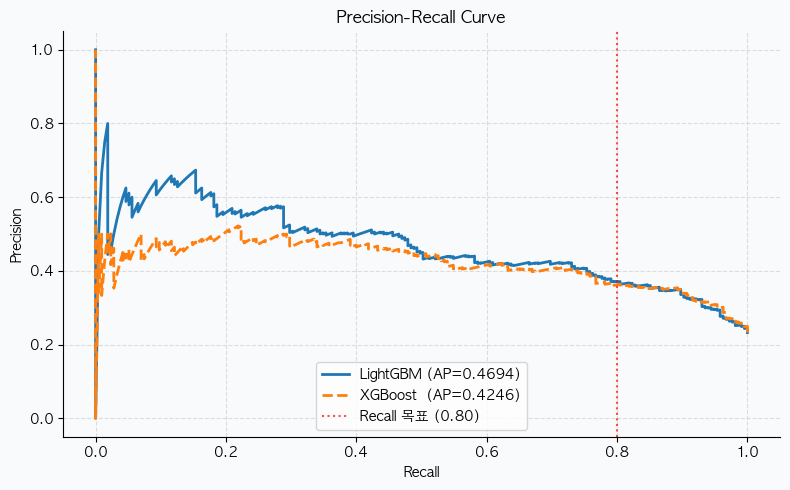

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Precision-Recall Curve
prec_lgbm, rec_lgbm, _ = precision_recall_curve(y_test, y_prob_lgbm)
prec_xgb,  rec_xgb,  _ = precision_recall_curve(y_test, y_prob_xgb)

ap_lgbm = average_precision_score(y_test, y_prob_lgbm)
ap_xgb  = average_precision_score(y_test, y_prob_xgb)

fig, ax = plt.subplots(figsize=(8, 5), facecolor='#F8FAFB')
ax.set_facecolor('#F8FAFB')

ax.plot(rec_lgbm, prec_lgbm, lw=2,
        label=f'LightGBM (AP={ap_lgbm:.4f})')
ax.plot(rec_xgb,  prec_xgb,  lw=2, linestyle='--',
        label=f'XGBoost  (AP={ap_xgb:.4f})')

ax.axvline(0.80, color='red', linestyle=':', alpha=0.7,
           label='Recall 목표 (0.80)')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(linestyle='--', alpha=0.4)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## STEP 18. SHAP 변수 중요도 분석
> 어떤 공정 변수가 불량 예측에 가장 크게 기여하는지 해석

In [49]:
import shap
import numpy as np

# SHAP 입력 데이터 준비 (범주형 dtype 맞추기)
X_test_shap = X_test.copy()
X_test_shap['Product_Type'] = X_test_shap['Product_Type'].astype('category')

explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test_shap)

# binary에서 [0,1] 리스트로 오는 경우 대응
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print("SHAP values shape:", sv.shape)
print("X_test shape:", X_test_shap.shape)

SHAP values shape: (924, 24)
X_test shape: (924, 24)


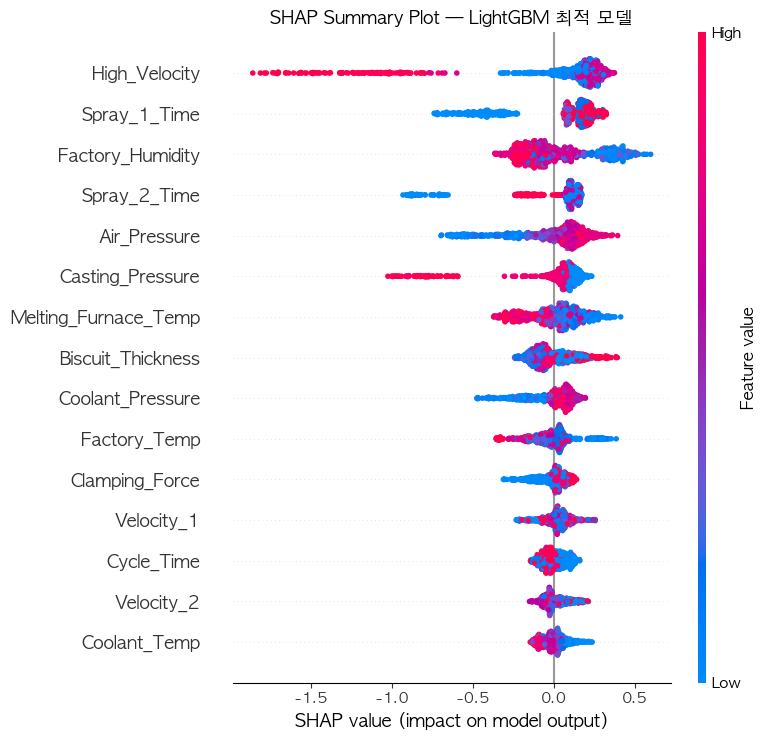

In [50]:
# Summary Plot (Beeswarm)
plt.figure(figsize=(10, 7))

shap.summary_plot(
    sv,
    X_test_shap,        # ✅ dtype 맞춘 데이터 사용
    max_display=15,
    show=False
)

plt.title('SHAP Summary Plot — LightGBM 최적 모델',
          fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

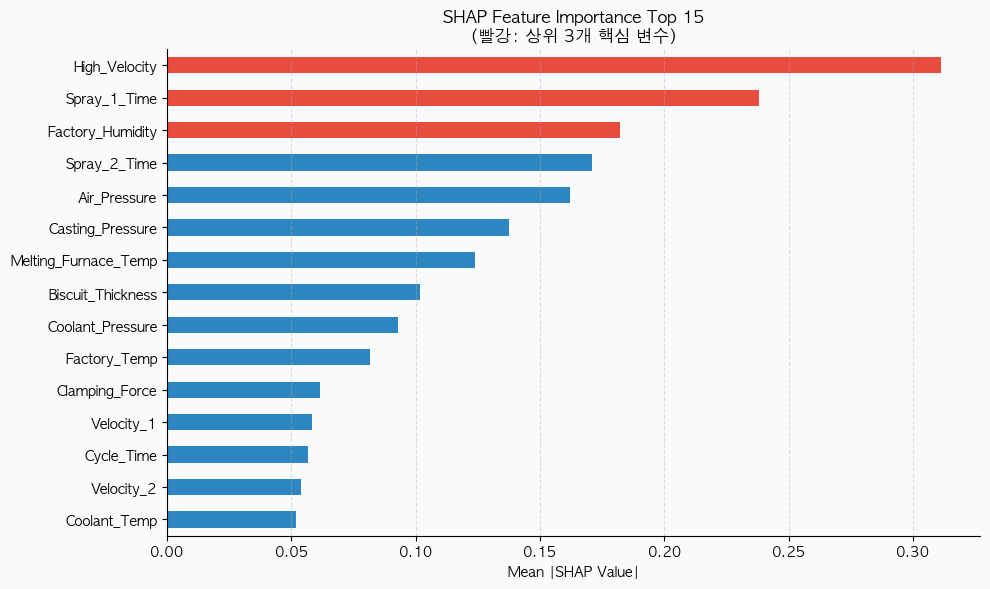


🏆 불량 예측 핵심 변수 TOP 5:
   #1  High_Velocity              SHAP=0.3114
   #2  Spray_1_Time               SHAP=0.2382
   #3  Factory_Humidity           SHAP=0.1821
   #4  Spray_2_Time               SHAP=0.1710
   #5  Air_Pressure               SHAP=0.1619


In [51]:
# Feature Importance Bar (SHAP)
cols = X_test_shap.columns  # ✅ 실제 입력 데이터 컬럼 순서 그대로 사용
mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#F8FAFB')
ax.set_facecolor('#F8FAFB')

topn = 15
bar_colors = ['#E74C3C' if i < 3 else '#2E86C1' for i in range(topn)]

mean_abs_shap.head(topn).iloc[::-1].plot(kind='barh', ax=ax, color=bar_colors[::-1])
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('SHAP Feature Importance Top 15\n(빨강: 상위 3개 핵심 변수)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print("\n🏆 불량 예측 핵심 변수 TOP 5:")
for i, (var, val) in enumerate(mean_abs_shap.head(5).items(), 1):
    print(f"   #{i}  {var:<25}  SHAP={val:.4f}")

## STEP 19. 전체 모델 성능 요약

In [52]:
# ✅ Baseline vs Tuning (Recall>=0.80 조건에서 F1 최대 threshold 적용) — 완성 코드

import numpy as np
import pandas as pd

from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score
)

TARGET_RECALL = 0.80

# ─────────────────────────────────────────
# 1) Constrained threshold 함수 (이 버전으로 "통일")
# ─────────────────────────────────────────
def find_best_threshold_constrained(y_true, y_prob, target_recall=0.80,
                                    thr_min=0.05, thr_max=0.95, step=0.01):
    """
    Recall >= target_recall 조건을 만족하는 threshold 중 F1이 최대인 threshold 반환.
    조건 만족 threshold가 없으면: F1 최대 threshold 반환 + ok=False
    """
    thresholds = np.arange(thr_min, thr_max + 1e-9, step)

    best = None
    best_any = None

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        r  = recall_score(y_true, y_pred, zero_division=0)
        p  = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        row = (thr, r, p, f1)

        # fallback: 조건 무시하고 F1 최대
        if (best_any is None) or (f1 > best_any[3]):
            best_any = row

        # 조건 만족 중 최고
        if r >= target_recall:
            if (best is None) or (f1 > best[3]):
                best = row

    if best is not None:
        thr, r, p, f1 = best
        ok = True
    else:
        thr, r, p, f1 = best_any
        ok = False

    return thr, r, p, f1, ok


# ─────────────────────────────────────────
# 2) 평가용 헬퍼
# ─────────────────────────────────────────
def eval_with_threshold(name, group, y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        '모델': name,
        '구분': group,
        '임계값': round(float(thr), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob), 4),
        'Recall≥0.80': '✅' if recall_score(y_true, y_pred, zero_division=0) >= TARGET_RECALL else '❌'
    }


# ─────────────────────────────────────────
# 3) XGBoost용 원-핫 (baseline에서도 필요)
#    * X_train / X_test는 "Product_Type이 category" 포함 가능
# ─────────────────────────────────────────
X_train_xgb = pd.get_dummies(X_train, columns=['Product_Type'], drop_first=True)
X_test_xgb  = pd.get_dummies(X_test,  columns=['Product_Type'], drop_first=True)
X_test_xgb  = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)


# ─────────────────────────────────────────
# 4) Baseline (각 모델별 Constrained thr 적용)
#    * baseline_models는 이미 정의되어 있어야 함
# ─────────────────────────────────────────
all_results = []

for name, model in baseline_models.items():

    # ✅ XGBoost만 원-핫 데이터로 학습/예측
    if 'XGBoost' in name:
        model.fit(X_train_xgb, y_train)
        yp = model.predict_proba(X_test_xgb)[:, 1]
    else:
        model.fit(X_train, y_train)
        yp = model.predict_proba(X_test)[:, 1]

    thr, _, _, _, _ = find_best_threshold_constrained(
        y_true=y_test,
        y_prob=yp,
        target_recall=TARGET_RECALL,
        thr_min=0.05, thr_max=0.95, step=0.01
    )

    all_results.append(eval_with_threshold(name, '베이스라인', y_test, yp, thr))
    print(f"✅ 베이스라인 {name} 완료 (thr={thr:.3f})")


# ─────────────────────────────────────────
# 5) Tuning 결과 추가
#    * y_prob_lgbm / opt_thr_lgbm, y_prob_xgb / opt_thr_xgb가 이미 계산되어 있어야 함
#    * opt_thr_* 는 constrained로 구해둔 값이어야 함
# ─────────────────────────────────────────
all_results.append(eval_with_threshold('LightGBM (튜닝)', '튜닝', y_test, y_prob_lgbm, opt_thr_lgbm))
all_results.append(eval_with_threshold('XGBoost  (튜닝)', '튜닝', y_test, y_prob_xgb,  opt_thr_xgb))


# ─────────────────────────────────────────
# 6) 최종 결과표
# ─────────────────────────────────────────
final_df = pd.DataFrame(all_results).sort_values(
    ['Recall≥0.80', 'F1-Score', 'Recall'],
    ascending=[False, False, False]
).reset_index(drop=True)

display(final_df)

✅ 베이스라인 Logistic Regression 완료 (thr=0.290)
✅ 베이스라인 Random Forest 완료 (thr=0.130)
✅ 베이스라인 XGBoost 완료 (thr=0.060)
✅ 베이스라인 LightGBM 완료 (thr=0.060)


,모델,구분,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM (튜닝),튜닝,0.43,0.8047,0.3712,0.5081,0.7637,✅
1,XGBoost (튜닝),튜닝,0.36,0.8930,0.3536,0.5066,0.7533,✅
2,LightGBM,베이스라인,0.06,0.8140,0.3431,0.4828,0.7244,✅
3,Random Forest,베이스라인,0.13,0.8744,0.3292,0.4784,0.7333,✅
4,XGBoost,베이스라인,0.06,0.8047,0.3321,0.4701,0.7034,✅
5,Logistic Regression,베이스라인,0.29,0.9581,0.2689,0.4200,0.6561,✅


In [53]:
import pickle

# ✅ 실제 학습에 사용한 컬럼을 저장 (순서 포함)
feature_cols = list(X_train.columns)

with open('model_final_lgbm.pkl', 'wb') as f:
    pickle.dump({
        'model':       best_lgbm,
        'threshold':   float(opt_thr_lgbm),     # ✅ 최종 threshold (Constrained 기준)
        'features':    feature_cols,            # ✅ 안전
        'target_recall': 0.80,                  # (선택) 기준 저장
        'note':        'LightGBM tuned; threshold chosen to maximize F1 under Recall>=0.80'
    }, f)

print("💾 최종 모델 저장 완료: model_final_lgbm.pkl")
print(f"   임계값(Constrained): {opt_thr_lgbm:.4f}")

best_row = final_df[final_df['모델'] == 'LightGBM (튜닝)'].iloc[0]
print(f"\n🏆 최종 선택: LightGBM (튜닝 + Constrained 임계값)")
print(f"   Recall   : {best_row['Recall']}")
print(f"   F1-Score : {best_row['F1-Score']}")
print(f"   ROC-AUC  : {best_row['ROC-AUC']}")

💾 최종 모델 저장 완료: model_final_lgbm.pkl
   임계값(Constrained): 0.4300

🏆 최종 선택: LightGBM (튜닝 + Constrained 임계값)
   Recall   : 0.8047
   F1-Score : 0.5081
   ROC-AUC  : 0.7637


---
## STEP 20. Product_Type별 분리 모델 비교
> 전체 통합 모델 vs Product_Type 1 / Product_Type 2 각각 학습 후 성능 비교

> **가설**: Type 1(불량률 17.6%)과 Type 2(28.6%)의 불량 패턴이 달라 분리 시 성능 향상 가능

In [54]:
# Product_Type별 분리 모델 비교
# Product_Type 컬럼 제외 (분리 모델에선 의미 없음)
FEATURES_SEP = [f for f in FEATURES if f != 'Product_Type']

def run_split_models(df_sub, label):
    X = df_sub[FEATURES_SEP].copy()
    y = df_sub['Defect_Status'].copy()

    if len(y.unique()) < 2:
        print(f"\n{label}: 클래스가 1개뿐이라 모델 학습 불가")
        return None

    pos_weight = (y==0).sum() / (y==1).sum()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED)

    X_train_xgb = pd.get_dummies(X_train)
    X_test_xgb  = pd.get_dummies(X_test).reindex(columns=X_train_xgb.columns, fill_value=0)

    models = {
        'Random Forest': RandomForestClassifier(
            n_estimators=200, class_weight='balanced',
            random_state=SEED, n_jobs=-1),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            scale_pos_weight=pos_weight, random_state=SEED, verbose=-1),
        'XGBoost': xgb.XGBClassifier(
            scale_pos_weight=pos_weight, n_estimators=200,
            random_state=SEED, eval_metric='logloss', verbosity=0),
    }

    results = []
    for name, model in models.items():
        if name == 'XGBoost':
            model.fit(X_train_xgb, y_train)
            yp = model.predict_proba(X_test_xgb)[:,1]
        else:
            model.fit(X_train, y_train)
            yp = model.predict_proba(X_test)[:,1]

        thr,r,p,f1,ok = find_best_threshold_constrained(y_test, yp, target_recall=0.80)
        auc = roc_auc_score(y_test, yp)
        results.append({
            '모델': name, '데이터': label,
            '임계값': round(thr,2),
            'Recall': round(r,4), 'Precision': round(p,4),
            'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
            'Recall≥0.80': '✅' if ok else '❌'
        })

    return pd.DataFrame(results).sort_values('F1-Score', ascending=False)

# ── 전체 / Type1 / Type2 실행
results_all  = run_split_models(df, '전체')
results_type1 = run_split_models(df[df['Product_Type']==1].copy(), 'Product_Type 1')
results_type2 = run_split_models(df[df['Product_Type']==2].copy(), 'Product_Type 2')

print("\n[ 전체 데이터 ]")
print(f"n={len(df)}, 불량률={df['Defect_Status'].mean()*100:.1f}%")
display(results_all)

print("\n[ Product_Type 1 ]")
print(f"n={len(df[df['Product_Type']==1])}, 불량률={df[df['Product_Type']==1]['Defect_Status'].mean()*100:.1f}%")
display(results_type1)

print("\n[ Product_Type 2 ]")
print(f"n={len(df[df['Product_Type']==2])}, 불량률={df[df['Product_Type']==2]['Defect_Status'].mean()*100:.1f}%")
display(results_type2)


[ 전체 데이터 ]
n=4617, 불량률=23.2%


,모델,데이터,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
1,LightGBM,전체,0.05,0.8326,0.3469,0.4897,0.7269,✅
0,Random Forest,전체,0.12,0.9023,0.3239,0.4767,0.7330,✅
2,XGBoost,전체,0.06,0.8047,0.3321,0.4701,0.7179,✅



[ Product_Type 1 ]
n=2653, 불량률=21.7%


,모델,데이터,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Random Forest,Product_Type 1,0.16,0.8174,0.3574,0.4974,0.7622,✅
1,LightGBM,Product_Type 1,0.05,0.6957,0.3865,0.4969,0.7675,❌
2,XGBoost,Product_Type 1,0.10,0.6609,0.3744,0.4780,0.7244,❌



[ Product_Type 2 ]
n=1964, 불량률=25.3%


,모델,데이터,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Random Forest,Product_Type 2,0.12,0.9091,0.3226,0.4762,0.7040,✅
2,XGBoost,Product_Type 2,0.06,0.6263,0.3584,0.4559,0.6845,❌
1,LightGBM,Product_Type 2,0.08,0.5455,0.3649,0.4372,0.6806,❌


In [ ]:
# 전체 vs 분리 모델 성능 비교 시각화
import matplotlib.pyplot as plt
import numpy as np

combined = pd.concat([results_all, results_type1, results_type2], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#F8FAFB')
metrics = ['Recall', 'F1-Score', 'ROC-AUC']
colors  = {'전체': '#2E86C1', 'Product_Type 1': '#27AE60', 'Product_Type 2': '#E67E22'}

for ax, metric in zip(axes, metrics):
    ax.set_facecolor('#F8FAFB')
    for i, (label, grp) in enumerate(combined.groupby('데이터')):
        x = np.arange(len(grp))
        ax.bar(x + i*0.25, grp[metric], width=0.25,
               label=label, color=list(colors.values())[i], alpha=0.85)

    if metric == 'Recall':
        ax.axhline(0.80, color='red', linestyle='--', lw=1.5, alpha=0.7, label='목표(0.80)')

    ax.set_xticks(np.arange(3) + 0.25)
    ax.set_xticklabels(['RF', 'LGBM', 'XGB'], fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)

plt.suptitle('전체 vs Product_Type별 분리 모델 성능 비교',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📌 분리 모델 비교 인사이트

| 구분 | 기대 효과 | 확인 포인트 |
|---|---|---|
| 분리 모델이 좋을 경우 | 유형별 패턴을 더 잘 학습 | F1, AUC 향상 |
| 통합 모델이 좋을 경우 | 데이터 양이 많아 일반화 유리 | 분리 시 데이터 부족 |

> Product_Type 2 불량률(28.6%)이 Type 1(17.6%)보다 높아
> 분리 시 Type 2 모델의 성능 향상이 기대됩니다.